#Capstone 3: Predicting iPSC Donor Differentiation Success

I this project we will use iPSC scRNA-seq data from a dataset of 125 donors to predict endoderm differntiation efficiency. This dataset if from the publication

Cuomo, A.S.E., Seaton, D.D., McCarthy, D.J. *et al.*  
**Single-cell RNA-sequencing of differentiating iPS cells reveals dynamic genetic effects on gene expression.**  
*Nature Communications*, 11, 810 (2020).  
https://doi.org/10.1038/s41467-020-14457-z

The dataset can be dowloaded at: https://zenodo.org/record/3625024#.Xil-0y2cZ0s

The code used in this original publication can be found on Github: https://github.com/single-cell-genetics/singlecell_endodiff_paper/tree/main

##Loading Data

In this notebook we will open the scRNA-seq counts from the file `raw_counts.csv` and check the quailty of the data. In this case, we will do EDA before Data Wrangling as the dataset provided as already undergone extensive cleaning and quality control in the original publication (see notebooks for `merging_and_qc` and `scrnaseq_preprocessing` in the github repository linked above).  We'll start with replicating key figures from the original publication as well as some original EDA relevant to our project. We'll then finish with some Data Wrangling to customize the dataset for modelling and save modified files.

In [ ]:
!pip install scanpy anndata seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.0 MB/s eta 0:00:00


In [ ]:
import sys

!pip install git+https://github.com/has2k1/scikit-misc.git

  Cloning https://github.com/has2k1/scikit-misc.git to /tmp/pip-req-build-5jjttm5y
  Running command git clone --filter=blob:none --quiet https://github.com/has2k1/scikit-misc.git /tmp/pip-req-build-5jjttm5y
  Resolved https://github.com/has2k1/scikit-misc.git to commit 12685083b3a26a0a21e756a6caa38fd812a40d67
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-misc: filename=scikit_misc-0.5.2-cp312-cp312-linux_x86_64.whl size=171089 sha256=c6c834ac443d36d5e46e9e55b349a3bab980b263c3a856e579c05c0f90204eec
  Stored in directory: /tmp/pip-ephem-wheel-cache-y2of8c3c/wheels/cf/88/67/58d30c2a2aeed927fe27197ee198c453b6c6568a9071da3191
Successfully built scikit-misc


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from __future__ import annotations
from matplotlib.pyplot import rc_context
from skmisc.loess import loess
import statsmodels.formula.api as smf
import scipy.sparse as sp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [ ]:
sce = pd.read_csv("/content/drive/MyDrive/Springboard/Capstone3_iPSC/raw_counts.csv")

In [ ]:
sce.head()

,Unnamed: 0,21843_1#10,21843_1#100,21843_1#101,21843_1#102,21843_1#103,21843_1#105,21843_1#106,21843_1#107,21843_1#108,...,24539_8#88,24539_8#89,24539_8#90,24539_8#91,24539_8#92,24539_8#93,24539_8#94,24539_8#95,24539_8#97,24539_8#98
0,ENSG00000000003_TSPAN6,64.776597,44.121248,74.626078,30.997329,57.660477,19.498058,69.878265,51.504546,34.788704,...,130.238399,130.237878,114.494744,210.255768,105.173273,47.907871,58.911664,55.278827,10.583646,12.802875
1,ENSG00000000419_DPM1,59.141261,33.543099,146.400605,107.131540,88.443606,40.283724,76.204119,71.771584,60.810112,...,213.313841,156.887467,216.422406,129.496649,135.092351,38.411454,78.819551,95.767302,4.019595,5.879611
2,ENSG00000000457_SCYL3,0.000174,0.140723,0.000000,0.853681,3.526533,0.178111,0.000000,1.605236,0.187650,...,0.028019,1.789482,0.037324,0.036428,4.626014,0.000000,0.035711,1.777117,0.667531,0.312050
3,ENSG00000000460_C1orf112,2.558570,11.291487,24.454294,44.679524,23.378878,15.807276,0.274687,10.208552,6.332066,...,58.638322,24.682619,8.207696,28.761178,34.322905,5.527773,2.366439,10.808463,2.049007,3.477908
4,ENSG00000001036_FUCA2,9.389441,6.909795,11.610768,13.620749,28.625064,4.008597,0.411931,23.029880,5.470056,...,17.105004,41.300051,26.138898,19.383468,10.116653,11.667776,3.726595,19.240578,1.968182,3.916709


Reset the index to the gene code and transform the df.

In [ ]:
sce.shape

(11231, 36045)

In [ ]:
sce.set_index("Unnamed: 0", inplace=True)

In [ ]:
sce.head()

,21843_1#10,21843_1#100,21843_1#101,21843_1#102,21843_1#103,21843_1#105,21843_1#106,21843_1#107,21843_1#108,21843_1#109,...,24539_8#88,24539_8#89,24539_8#90,24539_8#91,24539_8#92,24539_8#93,24539_8#94,24539_8#95,24539_8#97,24539_8#98
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003_TSPAN6,64.776597,44.121248,74.626078,30.997329,57.660477,19.498058,69.878265,51.504546,34.788704,8.105830,...,130.238399,130.237878,114.494744,210.255768,105.173273,47.907871,58.911664,55.278827,10.583646,12.802875
ENSG00000000419_DPM1,59.141261,33.543099,146.400605,107.131540,88.443606,40.283724,76.204119,71.771584,60.810112,72.615728,...,213.313841,156.887467,216.422406,129.496649,135.092351,38.411454,78.819551,95.767302,4.019595,5.879611
ENSG00000000457_SCYL3,0.000174,0.140723,0.000000,0.853681,3.526533,0.178111,0.000000,1.605236,0.187650,8.188757,...,0.028019,1.789482,0.037324,0.036428,4.626014,0.000000,0.035711,1.777117,0.667531,0.312050
ENSG00000000460_C1orf112,2.558570,11.291487,24.454294,44.679524,23.378878,15.807276,0.274687,10.208552,6.332066,7.652385,...,58.638322,24.682619,8.207696,28.761178,34.322905,5.527773,2.366439,10.808463,2.049007,3.477908
ENSG00000001036_FUCA2,9.389441,6.909795,11.610768,13.620749,28.625064,4.008597,0.411931,23.029880,5.470056,4.648160,...,17.105004,41.300051,26.138898,19.383468,10.116653,11.667776,3.726595,19.240578,1.968182,3.916709


In [ ]:
scet = sce.T

In [ ]:
print(sce.columns.tolist())

['21843_1#10', '21843_1#100', '21843_1#101', '21843_1#102', '21843_1#103', '21843_1#105', '21843_1#106', '21843_1#107', '21843_1#108', '21843_1#109', '21843_1#11', '21843_1#110', '21843_1#111', '21843_1#112', '21843_1#113', '21843_1#114', '21843_1#117', '21843_1#118', '21843_1#119', '21843_1#12', '21843_1#122', '21843_1#123', '21843_1#124', '21843_1#125', '21843_1#126', '21843_1#129', '21843_1#13', '21843_1#130', '21843_1#131', '21843_1#132', '21843_1#133', '21843_1#134', '21843_1#136', '21843_1#137', '21843_1#139', '21843_1#14', '21843_1#140', '21843_1#141', '21843_1#142', '21843_1#143', '21843_1#145', '21843_1#146', '21843_1#147', '21843_1#149', '21843_1#15', '21843_1#150', '21843_1#151', '21843_1#153', '21843_1#155', '21843_1#156', '21843_1#157', '21843_1#158', '21843_1#159', '21843_1#16', '21843_1#161', '21843_1#162', '21843_1#163', '21843_1#165', '21843_1#166', '21843_1#167', '21843_1#169', '21843_1#170', '21843_1#172', '21843_1#173', '21843_1#175', '21843_1#176', '21843_1#177', '

In [ ]:
scet.head()

Unnamed: 0,ENSG00000000003_TSPAN6,ENSG00000000419_DPM1,ENSG00000000457_SCYL3,ENSG00000000460_C1orf112,ENSG00000001036_FUCA2,ENSG00000001084_GCLC,ENSG00000001167_NFYA,ENSG00000001460_STPG1,ENSG00000001461_NIPAL3,ENSG00000001497_LAS1L,...,ENSG00000269955_LUC7L2,ENSG00000270011_ZNF559-ZNF177,ENSG00000270757_HSPE1-MOB4,ENSG00000270800_RPS10-NUDT3,ENSG00000270872_SRGAP2D,ENSG00000271043_MTRNR2L2,ENSG00000271303_SRXN1,ENSG00000272047_GTF2H5,ENSG00000272325_NUDT3,ENSG00000272398_CD24
21843_1#10,64.776597,59.141261,0.000174,2.558570,9.389441,0.132925,0.000000,16.237659,0.000000,68.755162,...,0.707747,0.321706,13.183170,9.742216,0.317078,733.516477,0.000000,2.357838,0.926892,7.171820
21843_1#100,44.121248,33.543099,0.140723,11.291487,6.909795,0.017055,9.349543,0.000000,0.000000,28.786504,...,0.814032,0.000000,2.665928,0.124172,0.184415,644.882756,0.000000,0.832917,1.333080,0.000000
21843_1#101,74.626078,146.400605,0.000000,24.454294,11.610768,19.969528,0.000000,6.241568,0.176881,46.033685,...,9.407085,0.000000,9.420499,1.442326,0.000000,1427.224279,0.400577,5.620285,6.006630,1.099184
21843_1#102,30.997329,107.131540,0.853681,44.679524,13.620749,5.888042,1.289695,0.000000,0.000000,14.404755,...,4.947101,0.000000,5.161977,4.227685,0.000000,735.502084,0.000000,4.152401,5.663919,3.203378
21843_1#103,57.660477,88.443606,3.526533,23.378878,28.625064,4.559106,3.774395,5.265652,0.179741,29.597788,...,2.016852,0.000000,4.454016,0.160515,0.000000,713.897664,0.000000,5.098191,2.164415,1.628816


Now we will load the metadata file.

In [ ]:
meta = pd.read_csv('/content/drive/MyDrive/Springboard/Capstone3_iPSC/cell_metadata_cols.tsv', sep='\t')

In [ ]:
meta.head()

,assigned,auxDir,cell_filter,cell_name,compatible_fragment_ratio,day,donor,expected_format,experiment,frag_dist_length,...,donor_short_id,donor_long_id,pseudo,PC1_top100hvgs,PC1_top200hvgs,PC1_top500hvgs,PC1_top1000hvgs,PC1_top2000hvgs,princ_curve,princ_curve_scaled01
21843_1#10,1,aux_info,True,21843_1#10,0.999497,day1,joxm,IU,expt_09,1001,...,joxm_1,HPSI0114i-joxm_1,0.292682,-13.353833,-12.969161,-11.769526,-12.153335,-12.871002,39.972588,0.352570
21843_1#100,1,aux_info,True,21843_1#100,0.999456,day1,fafq,IU,expt_09,1001,...,fafq_1,HPSI0314i-fafq_1,0.484716,2.399795,4.633188,5.131531,7.883242,9.916888,56.433387,0.497759
21843_1#101,1,aux_info,True,21843_1#101,0.999549,day1,fafq,IU,expt_09,1001,...,fafq_1,HPSI0314i-fafq_1,0.403809,-0.612621,0.006692,-0.643021,0.185298,-0.425978,52.966142,0.467177
21843_1#102,1,aux_info,True,21843_1#102,0.999422,day1,wuye,IU,expt_09,1001,...,wuye_2,HPSI1013i-wuye_2,0.260772,-11.946009,-12.691233,-14.508021,-15.328236,-18.071351,38.419984,0.338876
21843_1#103,1,aux_info,True,21843_1#103,0.999446,day1,joxm,IU,expt_09,1001,...,joxm_1,HPSI0114i-joxm_1,0.355366,-5.735735,-5.389405,-5.802985,-6.625860,-9.430127,48.488060,0.427679


The metadata columns that we are interested in are `cell_name` (or the index, which is same information), `day`, and `donor`.  

Cell_name = ID number  
Day = the day of differentiation, with day0 being iPSCs before the differentiation starts, day3 being final endoderm, and day1 - day2 being intermediate timepoints.  
Donor = a code given to each of the 125 different iPSC donors

However, I would like to go through some of the paper's figures before we start to customize this dataset to make sure that things are laid out and working as expected. For now I will only remove the PC1 etc columns, as they are an output of the original papers' code for PCA done in R and will definitly not be needed.

We'll use the ScanPy library to manage the data.

In [ ]:
meta = meta.iloc[: , 0:-7] #Remove unneeded PC columns

In [ ]:
meta.shape #Check

(36044, 86)

In [ ]:
adata = sc.AnnData(scet) #Make ScanPy object

In [ ]:
adata.obs = meta.loc[adata.obs_names] #Combine scanpy with metadata

In [ ]:
adata.layers['counts'] = adata.X.copy() #Stores raw counts in layer of the adata object so they're not lost during normalization
sc.pp.normalize_total(adata, target_sum=1e4) #Normalize counts
sc.pp.log1p(adata) #Log Transforms counts

In [ ]:
#Save to make a stop point
adata.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V1.h5ad")

In [ ]:
#Load file if necessary
#adata = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V1.h5ad")

##EDA: PCA, tSNE and UMAP
 Let's start EDA by replicating the PCA from Figure 1c and doing our own tSNE and UMAP plots.

 For the PCA, we'll use the 500 most variable genes, as was done in the publication.

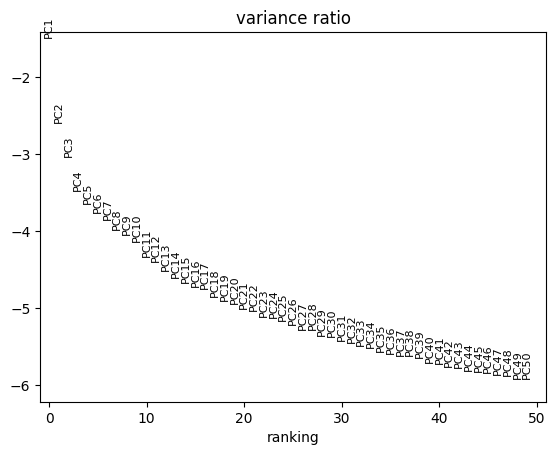

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=500, flavor='seurat', subset=False) #Define top 500 highly variable genes as True/False
adata_hvg = adata[:, adata.var.highly_variable].copy() #Subset data into the top most variable 500 genes
sc.tl.pca(adata_hvg)
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True) #Plot PC variance ratios

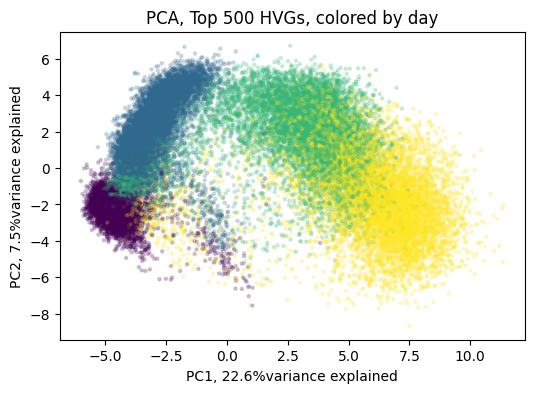

In [ ]:
perc_var = adata_hvg.uns['pca']['variance_ratio'] * 100
sc.tl.tsne(adata_hvg, use_rep='X_pca', random_state=147)
df = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'day': adata_hvg.obs['day'].values})

plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['day']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, colored by day')
plt.show()

Purple = day0  
Blue = day1  
Green = day2  
Yellow = day3  
The above graph nicely replicates the corresponding PCA from Figure 1c, which confirms that we have the correct dataset and are interpreting it correctly.  

Alternatively, we can color the PCA by batch, aka experiment.  Note that experiments appear evenly distributed, which tells us that the dataset has been effectively controlled for batch to batch variation during preprocessing.

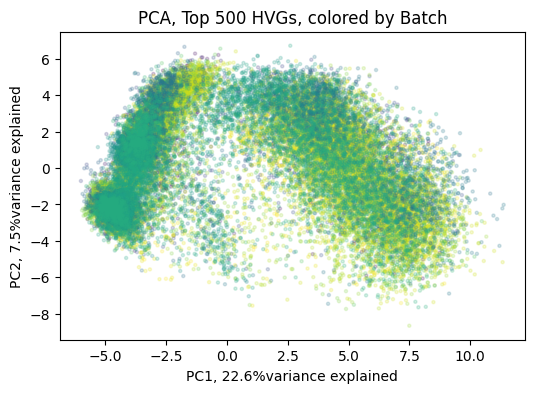

In [ ]:
df_exp = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'experiment': adata_hvg.obs['experiment'].values})
plt.figure(figsize=(6,4))
plt.scatter(df_exp['PC1'], df_exp['PC2'], c=pd.Categorical(df_exp['experiment']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, colored by Batch')
plt.show()

Now let's make a tSNE of the same data, this time colored by day.

tSNE = t-distributed Stochastic Nerighbor Embedding  
This plot puts similar data points close together and dissimilar data points farther apart on a scatter plot.  It is a standard tool in single cell RNAseq analysis, and often used for defining clusters.

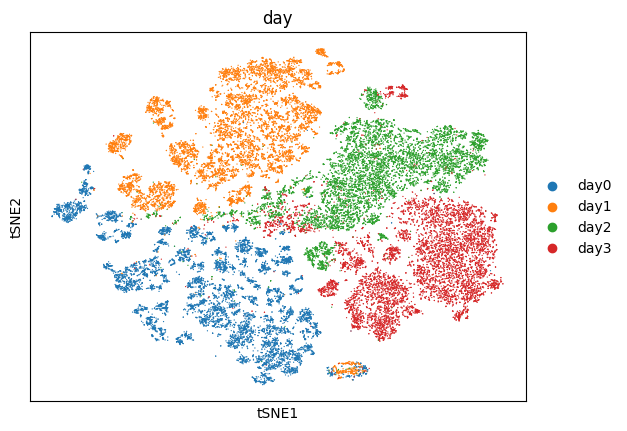

In [ ]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)
sc.tl.tsne(adata_hvg, n_pcs=40, perplexity=30)
sc.pl.tsne(adata_hvg, color="day")

And now a tSNE colored by donor.  We will only color 30 donors for visibility, as there are more donors than available colors.

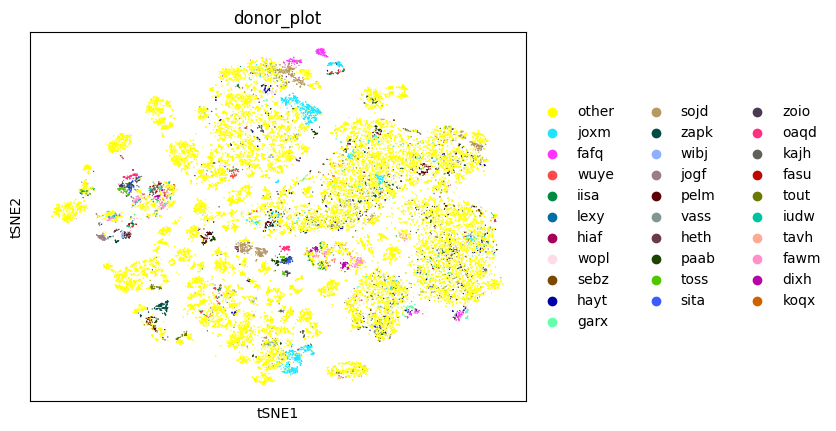

In [ ]:
donors = list(adata.obs['donor'].unique())
donors_sub = donors[:30]
adata_hvg.obs['donor_plot'] = adata_hvg.obs['donor'].astype(str).where(adata_hvg.obs['donor'].isin(donors_sub), 'other')
adata_hvg.obs['donor_plot'] = adata_hvg.obs['donor_plot'].astype('category')
adata_hvg.obs['donor_plot'] = adata_hvg.obs['donor_plot'].cat.reorder_categories(['other'] + donors_sub)

sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)
sc.tl.tsne(adata_hvg, n_pcs=40, perplexity=30)
sc.pl.tsne(adata_hvg, color="donor_plot")


We see that some donors are more evenly distributed than others.  This might be important later when we rank the differentiation capacity across donors.

Another easy first test that everything is working is a UMAP plot, this time for all genes (not just the top 50) which we will color by day.

UMAP = Uniform Manifold Approximation and Projection  
UMAPs are very similar to tSNEs, but use a differnt algorithm for definiting point similarities and sometimes can show different insights.

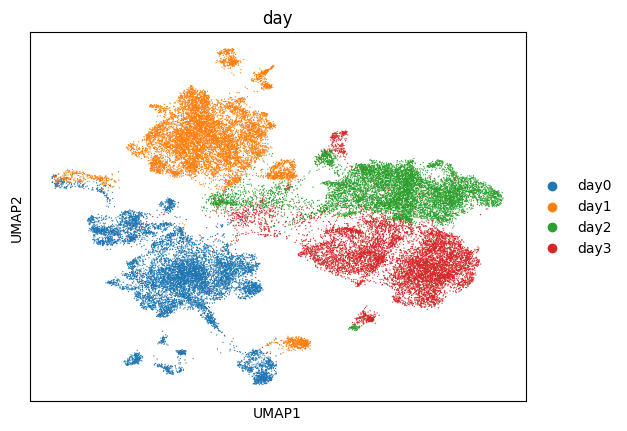

In [ ]:
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='day')


To verify that our actual time lines up with pseudotime predicted from cell stage, we can calculate pseudotime and overlay it on the PCA and UMAP.

In [ ]:
sc.tl.diffmap(adata) #Creates map of differences between cells
root_cells = adata.obs['day'] == 'day0'  #Picks random day0 cell as starting point
adata.uns['iroot'] = root_cells.values.nonzero()[0][0]  #Calculates pseudotime of other cells relative to root_cell
sc.tl.dpt(adata) #Adds dpt_pseudotime column to adata

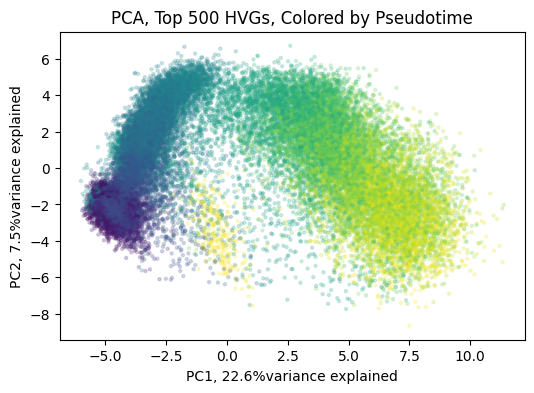

In [ ]:
df_pseudo = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'pseudotime': adata.obs['dpt_pseudotime'].values})
plt.figure(figsize=(6,4))
plt.scatter(df_pseudo['PC1'], df_pseudo['PC2'], c=pd.Categorical(df_pseudo['pseudotime']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, Colored by Pseudotime')
plt.show()

Remeber from the PCA colored by day (aka real time):  
Purple = day0  
Blue = day1  
Green = day2  
Yellow = day3  
The above plot shows that pseudotime and real time line up pretty well.  This gives us confidence in our differentiation and in our psueodtime calculations.

For completeness, let's color the UMAP by pseudotime as well.

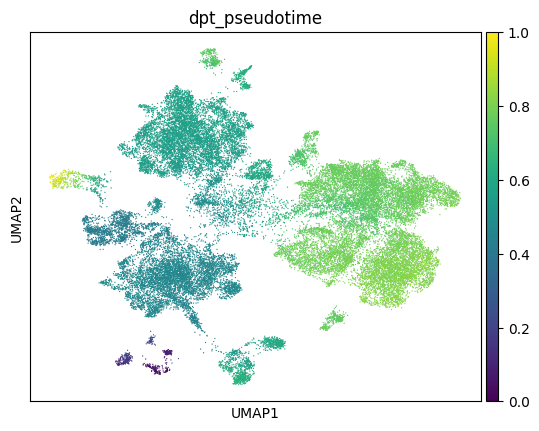

In [ ]:
sc.pl.umap(adata, color="dpt_pseudotime", cmap="viridis")

Looks pretty good!

In [ ]:
#Save to make a stop point
adata.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V2.h5ad")
adata_hvg.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_hvg_EDA_V1.h5ad")

In [ ]:
#Load file if necessary
#adata = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V2.h5ad")
#adata_hvg = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_hvg_EDA_V1.h5ad")

##EDA: Variable Gene Expression

As the iPSCs differentiate into endoderm cells, we expect their gene expression to change in a relatively predictable way.  For example, here we show how four classic markers of iPSC, intermediate endoderm and definitive endoderm change relative to pseudotime, as was shown in Figure 1d of the original publication.

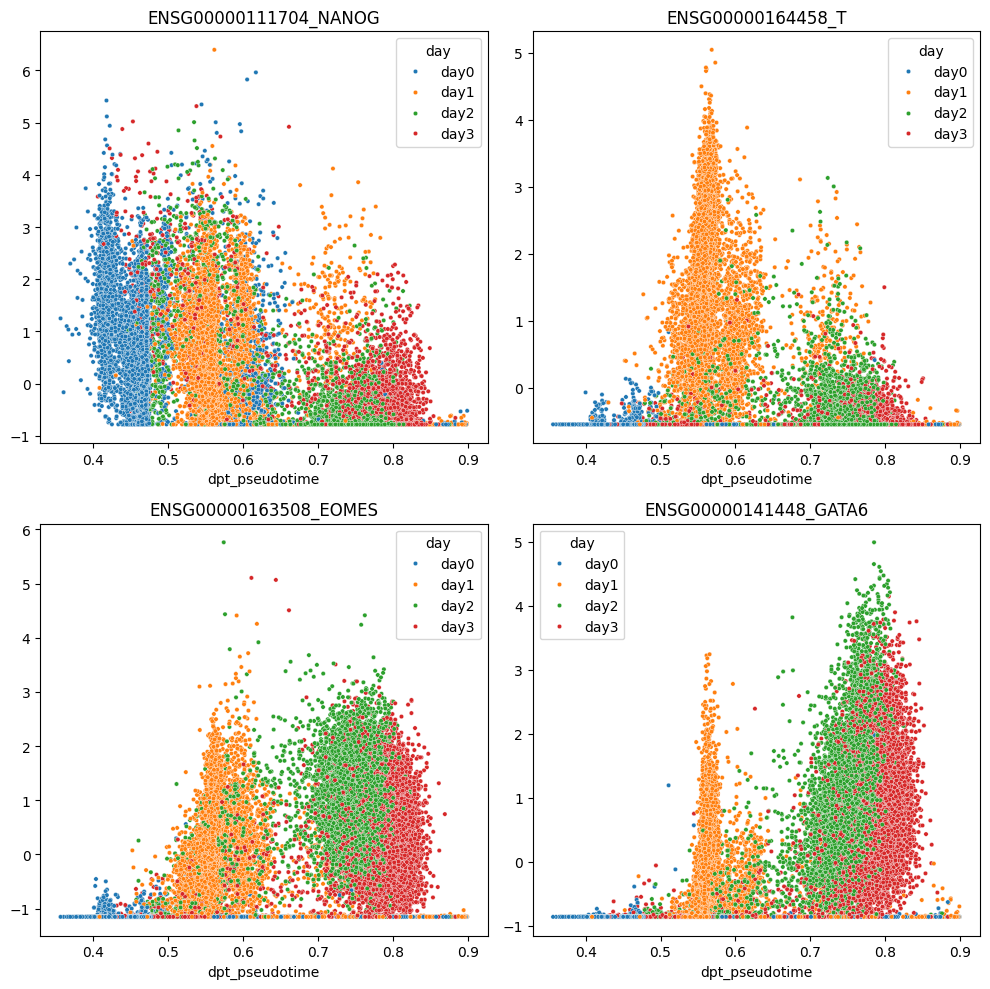

In [ ]:
#Gene symbols of Nanog for iPSCs, T (yes, this is actual gene name) and EOMES for intermediate endoderm, and GATA6 for definitive endoderm
diff_genes_reduced = ["ENSG00000111704_NANOG", "ENSG00000164458_T", "ENSG00000163508_EOMES", "ENSG00000141448_GATA6"]
adata_short = adata[(adata.obs['dpt_pseudotime'] >= 0.35) & (adata.obs['dpt_pseudotime'] <= 0.9)].copy() #The beginning and end of the pseudotime range are sparsely populated, so slice them out for better visibility
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, gene in enumerate(diff_genes_reduced):
    ax[i].set_title(gene)
    expr = adata_short[:, gene].X
    if hasattr(expr, "toarray"): #gene counts are stored as 2D matrices, so they must be flattened to plot
      expr = expr.toarray().flatten()
    else:
      expr = expr.flatten()
    sns.scatterplot(x=adata_short.obs['dpt_pseudotime'], y=expr, hue=adata_short.obs['day'], ax=ax[i], s=10)

plt.tight_layout()
plt.show()

Alternatively, we can look at the expression of these genes by day (aka real time).

/tmp/ipython-input-6986/990010404.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='day', y='expression', data=df, inner='quartile', scale='width', ax=ax[i])
/tmp/ipython-input-6986/990010404.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='day', y='expression', data=df, inner='quartile', scale='width', ax=ax[i])
/tmp/ipython-input-6986/990010404.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='day', y='expression', data=df, inner='quartile', scale='width', ax=ax[i])
/tmp/ipython-input-6986/990010404.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.

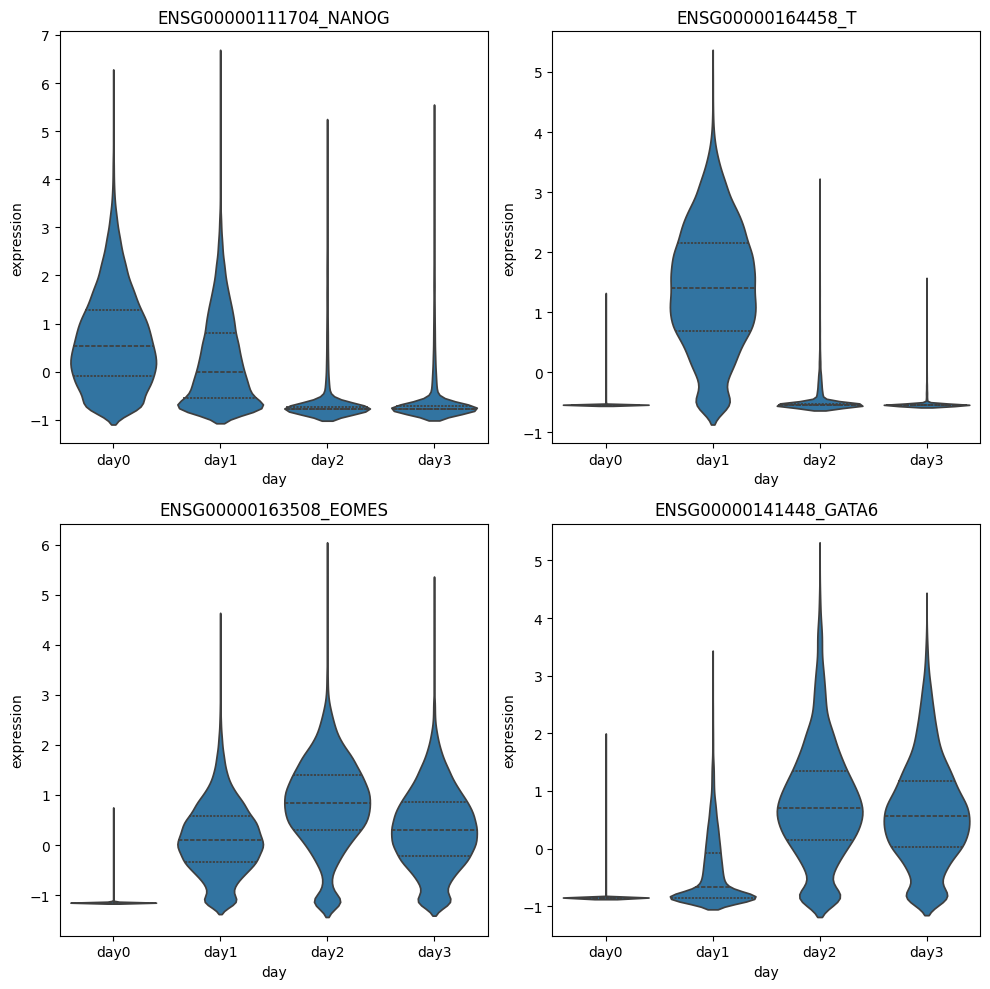

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, gene in enumerate(diff_genes_reduced):
    ax[i].set_title(gene)
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"): #gene counts are stored as 2D matrices, so they must be flattened to plot
      expr = expr.toarray().flatten()
    else:
      expr = expr.flatten()
    df = pd.DataFrame({'expression': expr, 'day': adata.obs['day'].values})
    sns.violinplot(x='day', y='expression', data=df, inner='quartile', scale='width', ax=ax[i])

plt.tight_layout()
plt.show()

These four marker genes follow the patterns you would expect for both pseudotime and real time.

We can look more broadly at changes in gene expression by either determining the genes that vary the most by time/pseudotime or by looking at larger lists of expected gene markers change over time/pseudotime.  We'll start with the genes that varied the most in real time.

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


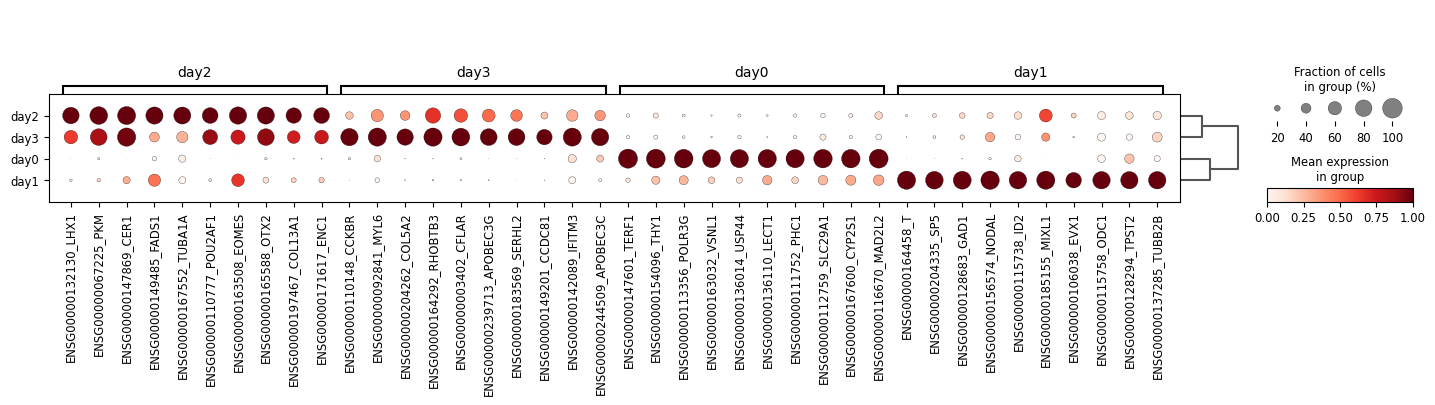

In [ ]:
day_order = ['day0', 'day1', 'day2', 'day3']
sc.tl.rank_genes_groups(adata, groupby='day', groups=day_order, method="wilcoxon") #Determine genes that are highest in each day, while being lowest in all other days
sc.pl.rank_genes_groups_dotplot(adata, groupby='day', standard_scale="var", n_genes=10) #Plot the top to variable genes for each day using the ScanPy dotplot function

I don't like that the scanpy version of this plot is not letting my control the day order, so for completeness I'll do the same plot in seaborn.

In [ ]:
#Find the top 10 most variable genes from previously calculated rank gene groups
n_genes = 10
top_genes = []
for day in day_order:
  genes = adata.uns['rank_genes_groups']['names'][day][:n_genes]
  top_genes.extend(genes)
top_genes = list(dict.fromkeys(top_genes))

In [ ]:
#Build data frame with from the gene name lists and calculate the fraction of cells expressing gene and the average expression by day, as would normally be done by the Scanpy dotplot function
dot_data = []

for gene in top_genes:
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    else:
        expr = expr.flatten()

    for day in day_order:
        mask = adata.obs['day'] == day # mask cells in this group
        group_expr = expr[mask]
        frac_expressing = np.mean(group_expr > 0) # compute fraction of expressing cells (>0)
        mean_expr = np.mean(group_expr) # compute average expression
        dot_data.append({"gene": gene, "day": day, "avg_expr": mean_expr, "frac_expressing": frac_expressing})

df_dot = pd.DataFrame(dot_data)
df_dot["day"] = pd.Categorical(df_dot["day"], categories=day_order, ordered=True)
df_dot["gene"] = pd.Categorical(df_dot["gene"], categories=top_genes, ordered=True)


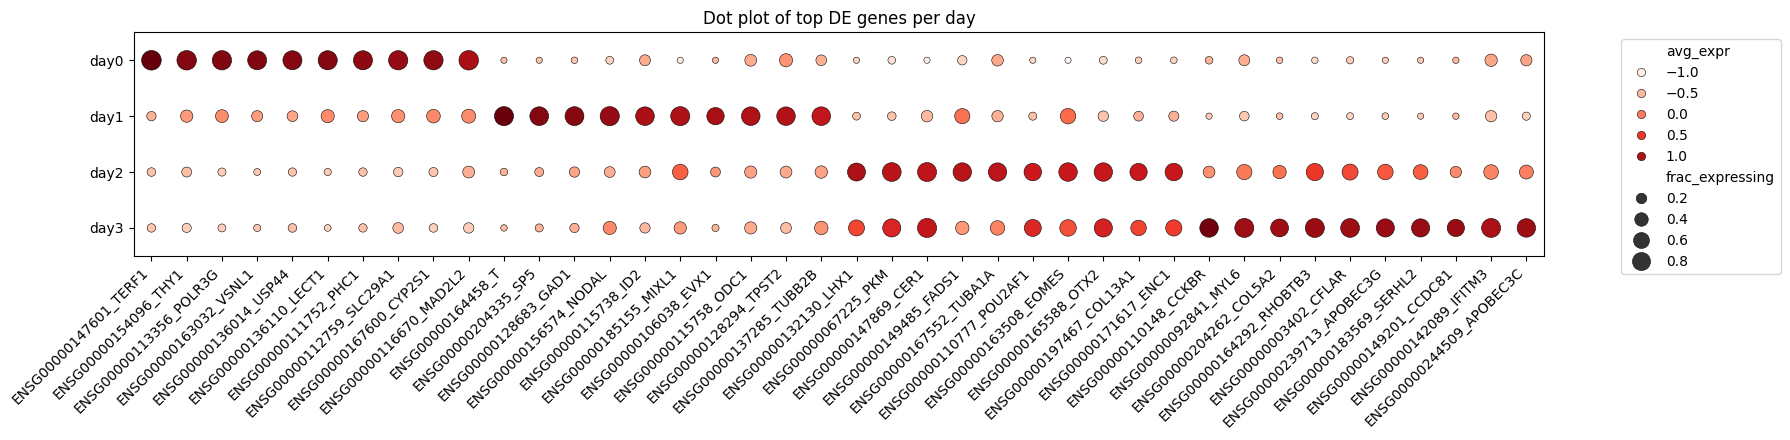

In [ ]:
#Plot dotplot as scatter plot, with contol over the day order
plt.figure(figsize=(18,4.5))
sns.scatterplot(
    data=df_dot,
    x="gene",
    y="day",
    size="frac_expressing",
    hue="avg_expr",
    palette="Reds",
    sizes=(20,200),
    edgecolor="k",
    legend="brief"
)
ax = plt.gca()
ax.set_ylim(len(day_order) - 0.5, -0.5)
ax.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.gca().set_xlim(-0.5, len(top_genes)-0.5)
plt.ylabel("")
plt.xlabel("")
plt.title("Dot plot of top DE genes per day")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

This confirms that we have nice differential expression accross days of the differentiation.  Alternatively, let's look at expression of larger groups of known iPSC and definitive endoderm (DE) markers.

List of DE markers is from:   
Zhang, Y., Yi, Y., Xiao, X. et al. Definitive Endodermal Cells Supply an in vitro Source of Mesenchymal Stem/Stromal Cells. Commun Biol 6, 476 (2023). https://doi.org/10.1038/s42003-023-04810-5

In [ ]:
# Build function that finds the column name in data for each gene symbol
def build_marker_list(symbols, adata):
  markers=[]
  for symbol in symbols:
    matches = [g for g in adata.var_names if g.endswith(f"_{symbol}")]
    if len(matches) == 1:
      markers.append(matches[0])
    elif len(matches) > 1:
      print(f"Multiple matches for {symbol}: {matches}")
    else:
      print(f"No matches for {symbol}")
  return markers

In [ ]:
#Lists of symbols for marker genes that are known to be high in definitive endoderm or iPSC, respectively.
de_symbols = [
    "SOX17","FOXA2","GATA6","GATA4","CXCR4",
    "LEFTY1","LEFTY2","TDGF1","STC1","OTX2",
    "FZD5","FGF17","SFRP1","ERBB4","SPOCK1","CCKBR", "EOMES", "GYPB", "PTGR1", "NPC2", "PKM", "KRT19", "GSC", "CER1"
]

ipsc_symbols = [
    "NANOG","POU5F1","SOX2", "MYC", "PODXL", "ALPL", "DNMT3B", "SPP1"
]
#Build lists of column names for the de and ipsc markers
de_markers = build_marker_list(de_symbols, adata)
ipsc_markers = build_marker_list(ipsc_symbols, adata)
markers = ipsc_markers + de_markers

In [ ]:
dot_markers = []

for gene in markers:
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    else:
        expr = expr.flatten()

    for day in day_order:
        mask = adata.obs['day'] == day # mask cells in this group
        group_expr = expr[mask]
        frac_expressing = np.mean(group_expr > 0) # compute fraction of expressing cells (>0)
        mean_expr = np.mean(group_expr) # compute average expression
        dot_markers.append({"gene": gene, "day": day, "avg_expr": mean_expr, "frac_expressing": frac_expressing})

df_markers = pd.DataFrame(dot_markers)
df_markers["day"] = pd.Categorical(df_markers["day"], categories=day_order, ordered=True)
df_markers["gene"] = pd.Categorical(df_markers["gene"], categories=markers, ordered=True)

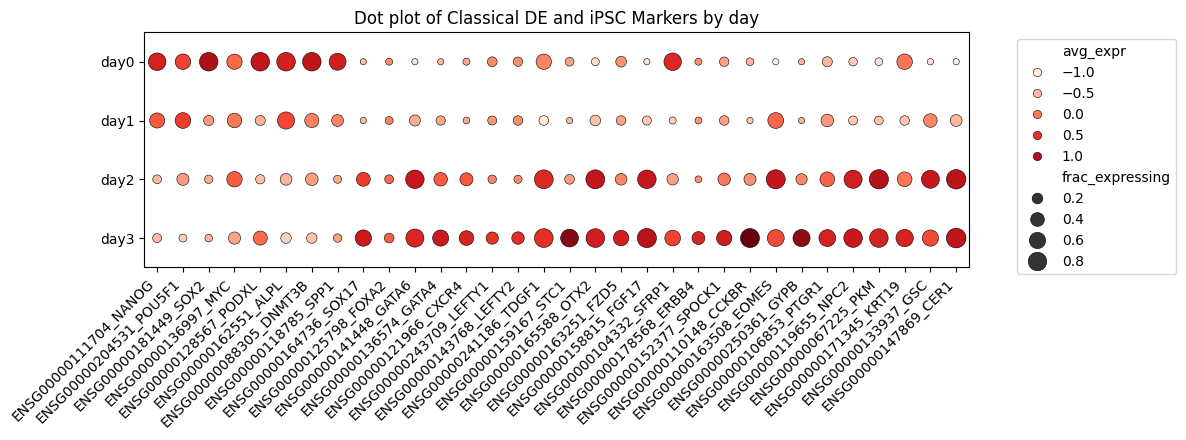

In [ ]:
plt.figure(figsize=(12,4.5))
sns.scatterplot(
    data=df_markers,
    x="gene",
    y="day",
    size="frac_expressing",
    hue="avg_expr",
    palette="Reds",
    sizes=(20,200),
    edgecolor="k",
    legend="brief"
)
ax = plt.gca()
ax.set_ylim(len(day_order) - 0.5, -0.5)
ax.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.gca().set_xlim(-0.5, len(markers)-0.5)
plt.ylabel("")
plt.xlabel("")
plt.title("Dot plot of Classical DE and iPSC Markers by day")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

Not bad at all.  The iPSC markers are high in iPSCs and go down as the differentiation proceeds.  The DE markers increase with differentiation and are higherst in day2/day3.  The above analysis has convinced me that the definitive endoderm differentiation was successful and we are free to continue with this dataset for our predictive modelling.

We can also look at differences in gene expression accross donors.  This is more complex since the differences in gene expression by donor are much more subtle that the difference in expression across days.  In order to find the genes which vary across donors, we must calculate the R2 value for each gene and sort out the genes with the highest R2.  

The following analysis will tell us:
1. How big to the R2 values get?  This will give us a sense of how much variability within a day can be attributed to donor.
2. Which genes vary the most by donor?  This could be useful for feature selection later during model building.

In [ ]:
#Define adata subsets for day0 and day3
adata_day0 = adata[adata.obs['day'] == 'day0']
adata_day3 = adata[adata.obs['day'] == 'day3']

In [ ]:
#Define function which uses OLS to calculate the R2 for each gene by donor
def donor_variance_by_gene(adata_subset):
  genes = adata_subset.var_names
  donor = adata_subset.obs['donor'].astype('category')
  r2 = []
  for g in genes:
    expr = adata_subset[:, g].X
    if hasattr(expr, "toarray"):
      expr = expr.toarray().flatten()
    else:
      expr = expr.flatten()
    df = pd.DataFrame({'expr': expr, 'donor': donor.values})
    model = smf.ols("expr ~ C(donor)", data=df).fit()
    r2.append(model.rsquared)
  return pd.Series(r2, index=genes)

In [ ]:
import statsmodels.formula.api as smf
r2_day0 = donor_variance_by_gene(adata_day0)
r2_day3 = donor_variance_by_gene(adata_day3)

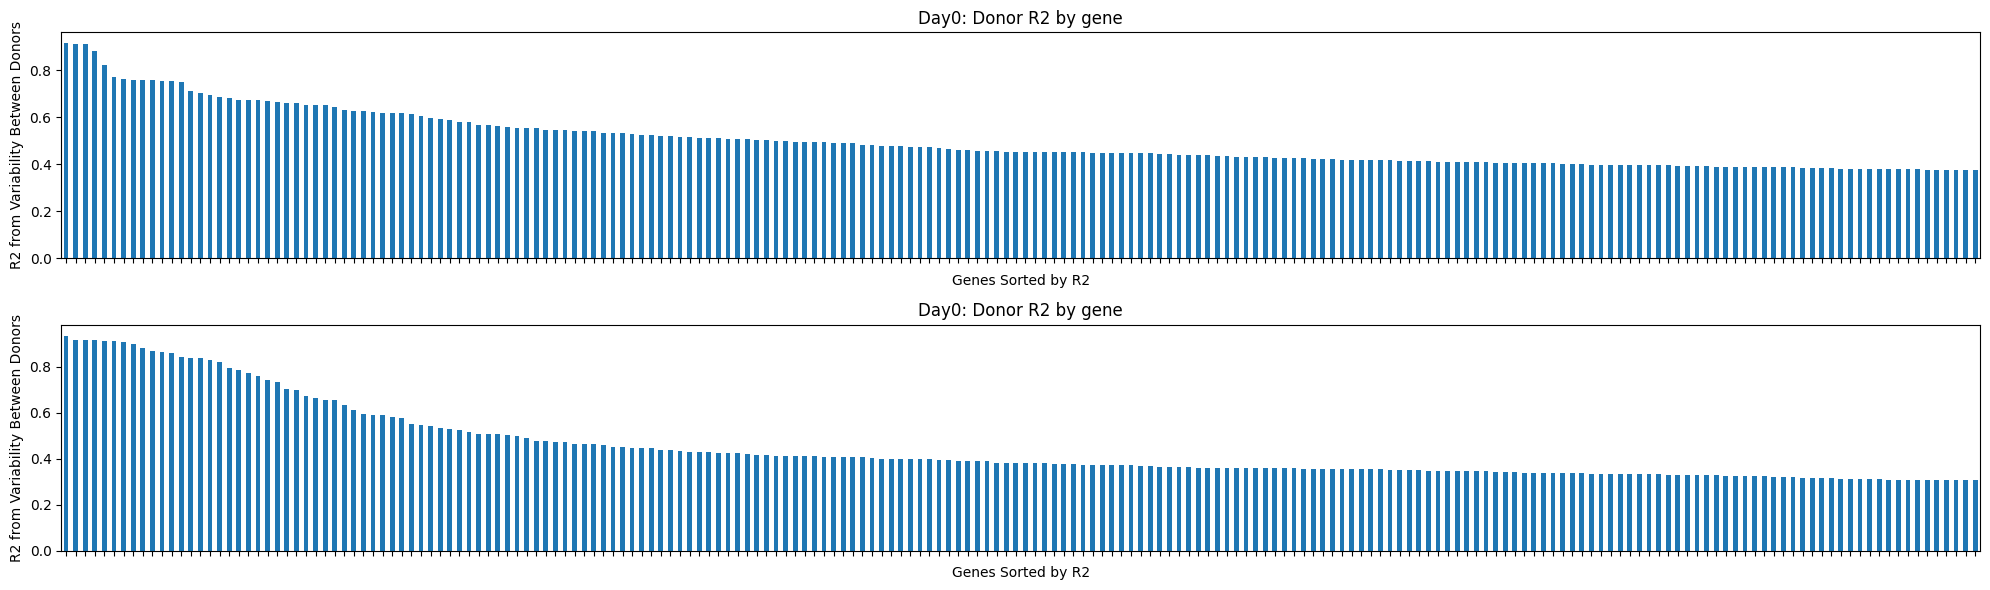

In [ ]:
r2_day0_sort = r2_day0.sort_values(ascending=False)
r2_day3_sort = r2_day3.sort_values(ascending=False)

fig, ax = plt.subplots(2, 1, figsize=(20, 6))
ax = ax.flatten()
ax[0] = r2_day0_sort.head(200).plot(kind='bar', ax=ax[0])
ax[1] = r2_day3_sort.head(200).plot(kind='bar', ax=ax[1])
ax[0].set_title('Day0: Donor R2 by gene')
ax[1].set_title('Day3: Donor R2 by gene')
ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[0].set_xlabel("Genes Sorted by R2")
ax[1].set_xlabel("Genes Sorted by R2")
ax[0].set_ylabel("R2 from Variability Between Donors")
ax[1].set_ylabel("R2 from Variability Between Donors")

plt.tight_layout()
plt.show()

The above plot confirms that there is measurable genetic variability between donors which can be leveraged for building our predictive model.

In [ ]:
#Find top 30 genes which vary by donor for day0 and day3
top_day0 = r2_day0.sort_values(ascending=False).head(30)
top_day3 = r2_day3.sort_values(ascending=False).head(30)

In [ ]:
top_day0

,0
Unnamed: 0,
ENSG00000204531_POU5F1,0.915984
ENSG00000230903_RPL9P8,0.910738
ENSG00000237550_UBE2Q2P6,0.910612
ENSG00000233927_RPS28,0.881590
ENSG00000163682_RPL9,0.822596
ENSG00000126768_TIMM17B,0.773076
ENSG00000272398_CD24,0.764867
ENSG00000206503_HLA-A,0.759137
ENSG00000271043_MTRNR2L2,0.758636


In [ ]:
top_day3

,0
Unnamed: 0,
ENSG00000198938_MT-CO3,0.936246
ENSG00000198727_MT-CYB,0.915961
ENSG00000198712_MT-CO2,0.915902
ENSG00000198899_MT-ATP6,0.915328
ENSG00000230903_RPL9P8,0.911881
ENSG00000237550_UBE2Q2P6,0.911824
ENSG00000198804_MT-CO1,0.907757
ENSG00000212907_MT-ND4L,0.898091
ENSG00000198888_MT-ND1,0.881453


From these tables, we can see that the majority of the variation within the days can be attributed to differences between donors for at least these 30 genes.  This level of variability supports our plan to use day0 data to predict day3 data (essentially).

For the day0 list, I want to point out that the most variable gene is POU5F1, aka Oct4, which is a famous iPSc marker and well known to be crucial in maintaining "stemness" in embryonic and induced pluripotent stem cells.  Oct4 is also one of the reprogramming factors used to turn donor material (skin or blood cells) into iPSCs.  The observation that this gene is highly variable between iPSCs from different donors bodes well for our modelling plan.

##EDA: Differentiation Efficiency Score

In order to build a predictive model, we need to have a target to predict.  For this purpose we will build a definitive endoderm (DE) score that we will use to rank the different donors. I will test two ways to build the DE score.

1. Calculate the average pseudotime for all day3 cells for a given donor. The closer to 1, to more differentiated the cells, the better.  This is the method used in Figure 5 of the original publication.

2. Calculate the average percentage of day3 cells expressing high levels of the DE markers and low levels of the iPSC markers that we plotted above.

For Method#1, calculting average donor day3 pseudotime, we must first answer the question of how many genes to use to calculate pseudotime.  

Step #1: Calculate pseudotime with all genes (already done), top 2000 HVGs or top 500 HVGs.  
Step #2: Color our PCA plot by each psuedotime and compare to PCA colored by day.  
Step #3: Plot gene expression of the four markers (NANOG, T, EOMES and GATA6) vs each pesuotime and visuall determine which makes the most sense.  
Step #4: Calculate the percent of cells whose day in real time overlaps with the appropaite range for each pseudtime (subjective ranges based on x-axis of markers scattersplots from Step#3).  
Step #5: Make a subjective choice based on all of these measurements.

###Ranking Donors: Method #1

In [ ]:
#Calculate pseudotime with top 500 HVGs
sc.pp.pca(adata_hvg)
sc.pp.neighbors(adata_hvg)
sc.tl.diffmap(adata_hvg)
root_cells = adata_hvg.obs['day'] == 'day0'
adata_hvg.uns['iroot'] = root_cells.values.nonzero()[0][0]
sc.tl.dpt(adata_hvg)

In [ ]:
# Add column to adata with new pseusotime to allow for comparable plots
adata.obs['500_pseudotime'] = adata_hvg.obs['dpt_pseudotime']

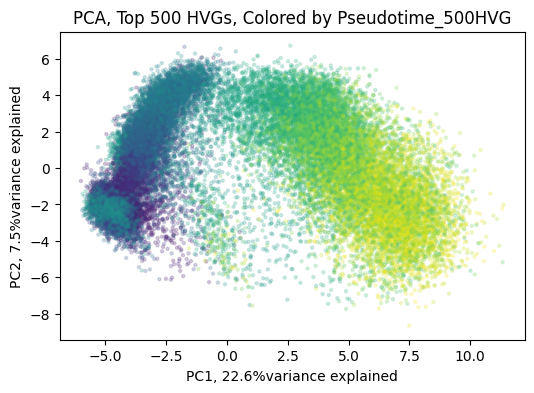

In [ ]:
#Color PCA with new 500 HVG pseudotime
df_pseudo = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'pseudotime': adata.obs['500_pseudotime'].values})
plt.figure(figsize=(6,4))
plt.scatter(df_pseudo['PC1'], df_pseudo['PC2'], c=pd.Categorical(df_pseudo['pseudotime']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, Colored by Pseudotime_500HVG')
plt.show()

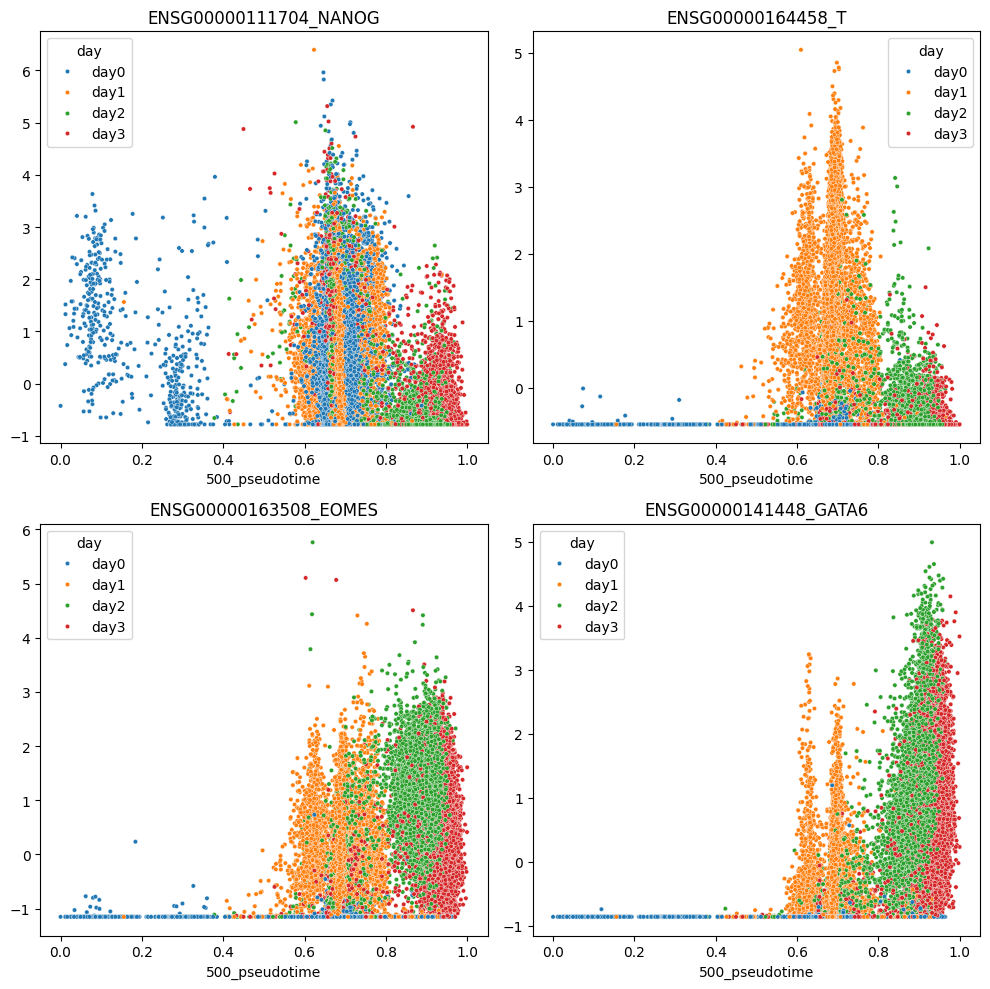

In [ ]:
# Plot markers vs new 500 HVG pseudotime
diff_genes_reduced = ["ENSG00000111704_NANOG", "ENSG00000164458_T", "ENSG00000163508_EOMES", "ENSG00000141448_GATA6"]
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, gene in enumerate(diff_genes_reduced):
    ax[i].set_title(gene)
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"): #gene counts are stored as 2D matrices, so they must be flattened to plot
      expr = expr.toarray().flatten()
    else:
      expr = expr.flatten()
    sns.scatterplot(x=adata.obs['500_pseudotime'], y=expr, hue=adata_hvg.obs['day'], ax=ax[i], s=10)

plt.tight_layout()
plt.show()

In [ ]:
#Calculate pseudotime with top 2000 HVGs
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', subset=False) #Define top 500 highly variable genes as True/False
adata_hvg2000 = adata[:, adata.var.highly_variable].copy() #Subset data into the top most variable 500 genes
sc.pp.pca(adata_hvg2000)
sc.pp.neighbors(adata_hvg2000)
sc.tl.diffmap(adata_hvg2000)
root_cells = adata_hvg2000.obs['day'] == 'day0'
adata_hvg2000.uns['iroot'] = root_cells.values.nonzero()[0][0]
sc.tl.dpt(adata_hvg2000)

In [ ]:
adata.obs['2000_pseudotime'] = adata_hvg2000.obs['dpt_pseudotime']

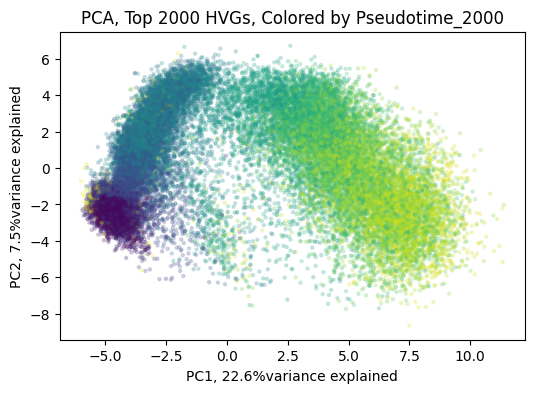

In [ ]:
#Color PCA with new 2000 HVG pseudotime
df_pseudo = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'pseudotime': adata.obs['2000_pseudotime'].values})
plt.figure(figsize=(6,4))
plt.scatter(df_pseudo['PC1'], df_pseudo['PC2'], c=pd.Categorical(df_pseudo['pseudotime']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 2000 HVGs, Colored by Pseudotime_2000')
plt.show()

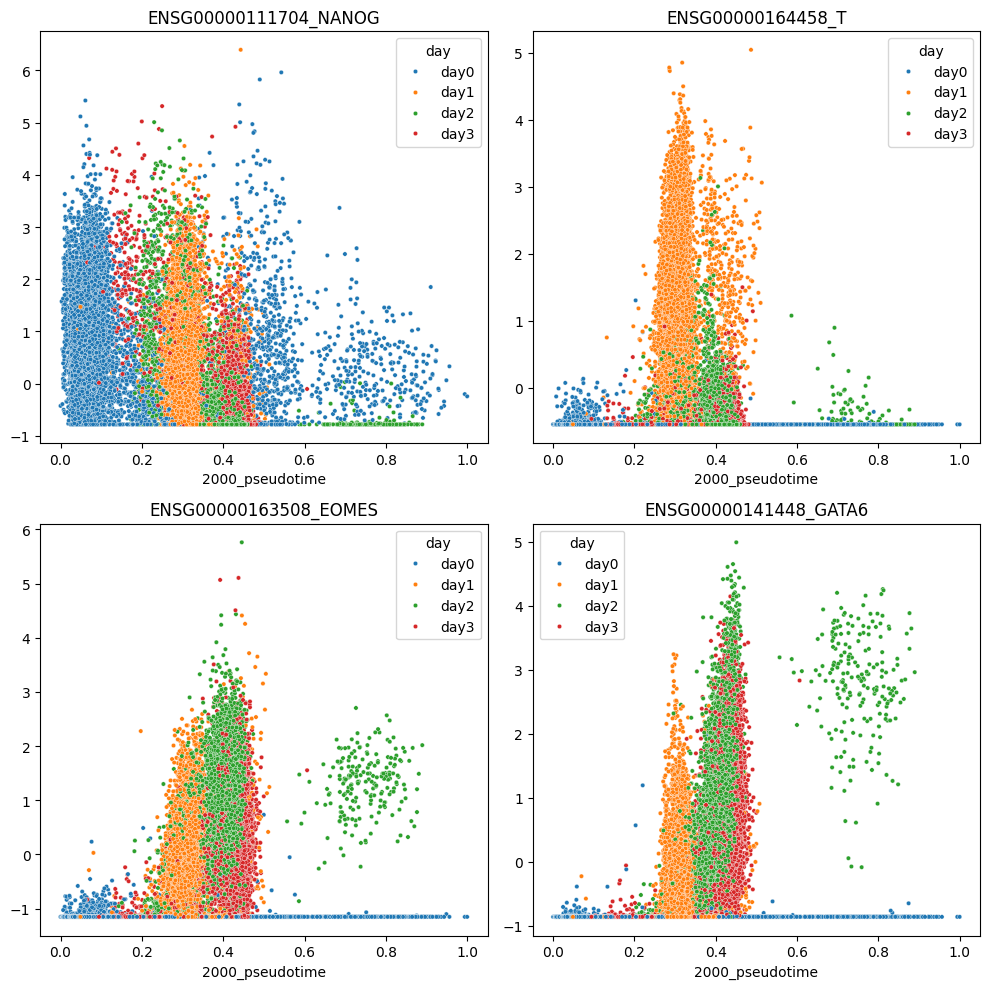

In [ ]:
# Plot markers vs new 2000 HVG pseudotime
diff_genes_reduced = ["ENSG00000111704_NANOG", "ENSG00000164458_T", "ENSG00000163508_EOMES", "ENSG00000141448_GATA6"]
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, gene in enumerate(diff_genes_reduced):
    ax[i].set_title(gene)
    expr = adata[:, gene].X
    if hasattr(expr, "toarray"): #gene counts are stored as 2D matrices, so they must be flattened to plot
      expr = expr.toarray().flatten()
    else:
      expr = expr.flatten()
    sns.scatterplot(x=adata.obs['2000_pseudotime'], y=expr, hue=adata_hvg.obs['day'], ax=ax[i], s=10)

plt.tight_layout()
plt.show()

Based on the above, 500 HVG pseudotime is awful.  I like the original pseudotime with all genes the best, but let's finish before making a decision.

In [ ]:
#Calculate the percent of day0 cells where pseudotime overlaps with realtime.
#NOTE!! Pseudotime is subjective! The range for "appropiate" pseudotime matching day0 was selected based on where the cells "should" lie on scatterplots for NANOG, T, EOMES and GATA6 vs each pseudotime.
# The means that the ranges are different for each pseudotime calculation, since the actual values are meaningless.
day0_pseudo_2000 = (len(adata[(adata.obs['day'] == 'day0') & (adata.obs['2000_pseudotime'] <= 0.2)]) / len(adata[adata.obs['day'] == 'day0']))*100
day0_pseudo_500 = (len(adata[(adata.obs['day'] == 'day0') & (adata.obs['500_pseudotime'] <= 0.5)]) / len(adata[adata.obs['day'] == 'day0']))*100
day0_pseudo = (len(adata[(adata.obs['day'] == 'day0') & (adata.obs['dpt_pseudotime'] <= 0.55)]) / len(adata[adata.obs['day'] == 'day0']))*100
print(f"{day0_pseudo:.2f}% of day0 cells have day0 pseudotime when pseudotime is calculated with all genes.")
print(f"{day0_pseudo_2000:.2f}% of day0 cells have day0 pseudotime when pseudotime is calculated with top 2000 HVGs.")
print(f"{day0_pseudo_500:.2f}% of day0 cells have day0 pseudotime when pseudotime is calculated with top 500 HVGs.")

91.58% of day0 cells have day0 pseudotime when pseudotime is calculated with all genes.
80.48% of day0 cells have day0 pseudotime when pseudotime is calculated with top 2000 HVGs.
5.43% of day0 cells have day0 pseudotime when pseudotime is calculated with top 500 HVGs.


In [ ]:
#Calculate the percent of day1 cells where pseudotime overlaps with realtime.
day1_pseudo_2000 = (len(adata[(adata.obs['day'] == 'day1') & ((adata.obs['2000_pseudotime'] <= 0.35) & (adata.obs['2000_pseudotime'] >= 0.2))]) / len(adata[adata.obs['day'] == 'day1']))*100
day1_pseudo_500 = (len(adata[(adata.obs['day'] == 'day1') & ((adata.obs['500_pseudotime'] <= 0.8) & (adata.obs['500_pseudotime'] >= 0.55))]) / len(adata[adata.obs['day'] == 'day1']))*100
day1_pseudo = (len(adata[(adata.obs['day'] == 'day1') & ((adata.obs['dpt_pseudotime'] <= 0.65) & (adata.obs['dpt_pseudotime'] >= 0.5))]) / len(adata[adata.obs['day'] == 'day1']))*100
print(f"{day1_pseudo:.2f}% of day1 cells have day1 pseudotime when pseudotime is calculated with all genes.")
print(f"{day1_pseudo_2000:.2f}% of day1 cells have day1 pseudotime when pseudotime is calculated with top 2000 HVGs.")
print(f"{day1_pseudo_500:.2f}% of day1 cells have day1 pseudotime when pseudotime is calculated with top 500 HVGs.")

93.91% of day1 cells have day1 pseudotime when pseudotime is calculated with all genes.
91.99% of day1 cells have day1 pseudotime when pseudotime is calculated with top 2000 HVGs.
97.46% of day1 cells have day1 pseudotime when pseudotime is calculated with top 500 HVGs.


In [ ]:
#Calculate the percent of day2 cells where pseudotime overlaps with realtime.
day2_pseudo_2000 = (len(adata[(adata.obs['day'] == 'day2') & ((adata.obs['2000_pseudotime'] <= 0.45) & (adata.obs['2000_pseudotime'] >= 0.35))]) / len(adata[adata.obs['day'] == 'day2']))*100
day2_pseudo_500 = (len(adata[(adata.obs['day'] == 'day2') & ((adata.obs['500_pseudotime'] <= 0.9) & (adata.obs['500_pseudotime'] >= 0.8))]) / len(adata[adata.obs['day'] == 'day2']))*100
day2_pseudo = (len(adata[(adata.obs['day'] == 'day2') & ((adata.obs['dpt_pseudotime'] <= 0.8) & (adata.obs['dpt_pseudotime'] >= 0.65))]) / len(adata[adata.obs['day'] == 'day2']))*100
print(f"{day2_pseudo:.2f}% of day2 cells have day2 pseudotime when pseudotime is calculated with all genes.")
print(f"{day2_pseudo_2000:.2f}% of day2 cells have day2 pseudotime when pseudotime is calculated with top 2000 HVGs.")
print(f"{day2_pseudo_500:.2f}% of day2 cells have day2 pseudotime when pseudotime is calculated with top 500 HVGs.")

88.87% of day2 cells have day2 pseudotime when pseudotime is calculated with all genes.
86.03% of day2 cells have day2 pseudotime when pseudotime is calculated with top 2000 HVGs.
38.53% of day2 cells have day2 pseudotime when pseudotime is calculated with top 500 HVGs.


In [ ]:
#Calculate the percent of day1 cells where pseudotime overlaps with realtime.
day3_pseudo_2000 = (len(adata[(adata.obs['day'] == 'day3') & (adata.obs['2000_pseudotime'] >= 0.35)]) / len(adata[adata.obs['day'] == 'day3']))*100
day3_pseudo_500 = (len(adata[(adata.obs['day'] == 'day3') & (adata.obs['500_pseudotime'] >= 0.85)]) / len(adata[adata.obs['day'] == 'day3']))*100
day3_pseudo = (len(adata[(adata.obs['day'] == 'day3') & (adata.obs['dpt_pseudotime'] >= 0.7)]) / len(adata[adata.obs['day'] == 'day3']))*100
print(f"{day3_pseudo:.2f}% of day3 cells have day3  pseudotime when pseudotime is calculated with all genes.")
print(f"{day3_pseudo_2000:.2f}% of day3 cells have day3 pseudotime when pseudotime is calculated with top 2000 HVGs.")
print(f"{day3_pseudo_500:.2f}% of day3 cells have day3  pseudotime when pseudotime is calculated with top 500 HVGs.")

93.18% of day3 cells have day3  pseudotime when pseudotime is calculated with all genes.
93.95% of day3 cells have day3 pseudotime when pseudotime is calculated with top 2000 HVGs.
92.66% of day3 cells have day3  pseudotime when pseudotime is calculated with top 500 HVGs.


Decision: Pseudotime calculated from all genes seems the most accurate.
- High percentage of cells match real time, especially
- Best separation of day2 and day3, which tend to overlap
- Uses most of the range of 0 to 1 for majority of cells, to allow for better differentiation betwen donors.

Now that we have selected a pseudotime, we can calculate average day3 pseudotime by donor.

In [ ]:
adata_pseudorank = adata.obs.groupby(['day', 'donor'], observed=True).agg(mean_pseudotime=('dpt_pseudotime', 'mean')).reset_index()
adata_pseudorank_pivot = adata_pseudorank.pivot(index='donor', columns='day', values='mean_pseudotime')
adata_pseudorank_pivot

day,day0,day1,day2,day3
donor,,,,
aowh,0.463758,0.560893,0.762707,0.795710
aoxv,0.463676,0.565344,0.754454,0.792407
babz,0.594133,NaN,0.717042,NaN
bezi,0.465387,0.548795,0.532747,0.704033
bima,NaN,NaN,0.734669,0.740557
...,...,...,...,...
zagm,0.470738,0.558133,0.765701,0.793902
zapk,0.364994,NaN,0.754705,0.719840
zerv,0.416967,0.556565,0.755207,NaN


In [ ]:
adata_pseudorank_pivot.isna().sum()

,0
day,
day0,14
day1,14
day2,21
day3,17


In [ ]:
adata_pseudorank_clean = adata_pseudorank_pivot.dropna(subset=['day0', 'day3'])
adata_pseudorank_clean.shape

(96, 4)

In [ ]:
adata_pseudorank_clean_long = adata_pseudorank_clean.reset_index().melt(id_vars='donor', var_name='day', value_name='mean_pseudotime')
adata_pseudorank_clean_long

,donor,day,mean_pseudotime
0,aowh,day0,0.463758
1,aoxv,day0,0.463676
2,bezi,day0,0.465387
3,bokz,day0,0.458532
4,cicb,day0,0.492554
...,...,...,...
379,yelp,day3,0.798859
380,yemz,day3,0.808366
381,yoch,day3,0.794238
382,zagm,day3,0.793902


<function matplotlib.pyplot.show(close=None, block=None)>

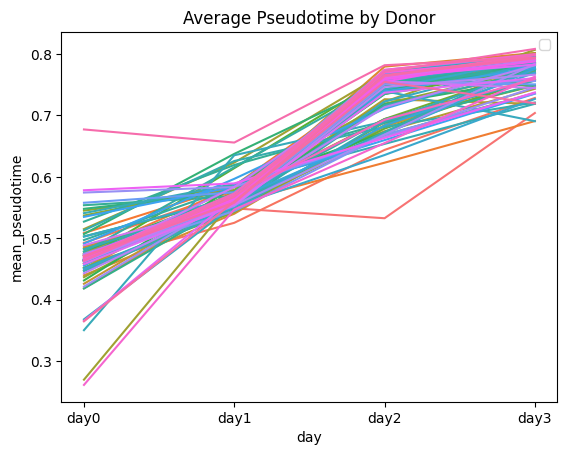

In [ ]:
sns.lineplot(data=adata_pseudorank_clean_long, x='day', y='mean_pseudotime', hue='donor')
plt.title('Average Pseudotime by Donor')
plt.legend('')
plt.show

This method works for most donors, but there is a huge range in pseudotime for day0.  This is probably because of the ~10% of day0 cells who don't have a pseudotime less than 0.55.

We have two options - We could leave it as it since this is how data often looks and see what happens in the model development, or we could see what the dataset looks like if we remove the day0 cells with dpt_pseudotime above 0.55.  Let's try removing them as see what we get.

<function matplotlib.pyplot.show(close=None, block=None)>

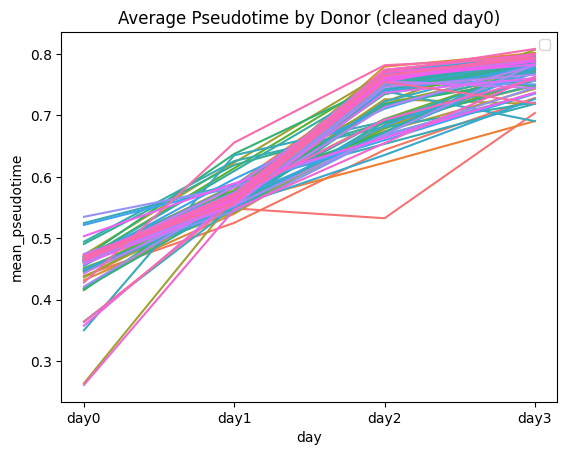

In [ ]:
adata_short = adata[~((adata.obs['day'] == 'day0') & (adata.obs['dpt_pseudotime'] >= 0.55))].copy()
adata_short_pseudorank = adata_short.obs.groupby(['day', 'donor'], observed=True).agg(mean_pseudotime=('dpt_pseudotime', 'mean')).reset_index()
adata_short_pseudorank_pivot = adata_short_pseudorank.pivot(index='donor', columns='day', values='mean_pseudotime')
adata_short_pseudorank_clean = adata_short_pseudorank_pivot.dropna(subset=['day0', 'day3'])
adata_short_pseudorank_clean_long = adata_short_pseudorank_clean.reset_index().melt(id_vars='donor', var_name='day', value_name='mean_pseudotime')

sns.lineplot(data=adata_short_pseudorank_clean_long, x='day', y='mean_pseudotime', hue='donor')
plt.title('Average Pseudotime by Donor (cleaned day0)')
plt.legend('')
plt.show

In [ ]:
adata_short_pseudorank_clean_long['donor'].nunique()

96

In [ ]:
adata_pseudorank_clean_long['donor'].nunique()

96

In [ ]:
adata_short.shape

(35231, 11231)

If we remove the day0 iPSCs with a pseudotime above 0.55 from the dataset, we lose 1000 cells and no donors from our dataset.  This seems like a reasonable sacrifice for cleaner data.  If we go with the pseudotime method of ranking our donors, I recommend removing these cells from the final dataset during Data Wrangling.

In [ ]:
adata_short_pseudorank_clean_long_day3 = adata_short_pseudorank_clean_long[adata_short_pseudorank_clean_long['day'] == 'day3']
adata_short_pseudorank_clean_long_day3.shape

(96, 3)

In [ ]:
donor_to_mean = adata_short_pseudorank_clean_long_day3.set_index('donor')['mean_pseudotime']
adata.obs['mean_pseudorank'] = adata.obs['donor'].map(donor_to_mean)
adata_short.obs['mean_pseudorank'] = adata_short.obs['donor'].map(donor_to_mean)

In [ ]:
#Save to make a stop point
adata.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V3.h5ad")
adata_hvg.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_hvg_EDA_V2.h5ad")
adata_short.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_EDA_V3.h5ad")

In [ ]:
#Load file if necessary
#adata = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V3.h5ad")
#adata_hvg = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_hvg_EDA_V2.h5ad")
#adata_short = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_EDA_V3.h5ad")

###Ranking Donors: Method #2

Now we will try creating a DE_score that we can use to rank the cells rather than pseudotime.

The first question is, what genes should we use to make a score?  Cell-state scores are generally made by taking the mean expression of genes high in the cells state of interest and substracting the mean expression of genes typically low in the cell type of interest.  For DE cells, this looks like:

DE_score = mean(DE high genes) - mean(DE low genes)

Fortunatly Scanpy has this as a more sophisticated function already: `score_genes`

So what genes do we use?  One option is the to use the list of confirmed markers we already looked at, but these lists are quite short.  

Another option is make lists of all the genes that are high/low in day3 cells in the dataset we have.  However, this has the potential to be too self-affirming and tell us which cells are the most extreme in our dataset, as opposed to which cells are the closest to 'real' DE.

A third option is to find a list from a similar dataset that also did single cell RNA-seq on DE or iPSC-derived DE cells.

**Solution: Make gene lists from this dataset and an independent dataset.  Keep the overlapping genes.  Add in any genes from our confirmed marker lists that are missing.**

Note: It's not abnormal for known markers to be excluded from lists like this, as marker gene do not always follow the filtering rules we use to find highly expressed genes.

To start, we will use the dataset from the following publication, which analyzes scRNA-seq data from iPSC derived DE cells.

Chu LF, Leng N, Zhang J, Hou Z, Mamott D, Vereide DT, Choi J, Kendziorski C, Stewart R, Thomson JA. Single-cell RNA-seq reveals novel regulators of human embryonic stem cell differentiation to definitive endoderm. Genome Biol. 2016 Aug 17;17(1):173. doi: 10.1186/s13059-016-1033-x. PMID: 27534536; PMCID: PMC4989499.

In [ ]:
DE_df = pd.read_csv("/content/drive/MyDrive/Springboard/Capstone3_iPSC/Capstone3_iPSC_EDA/DE_markers/GSE75748_sc_cell_type_ec.csv", index_col=0)

In [ ]:
DE_df

,H1_Exp1.001,H1_Exp1.002,H1_Exp1.003,H1_Exp1.004,H1_Exp1.006,H1_Exp1.007,H1_Exp1.008,H1_Exp1.009,H1_Exp1.010,H1_Exp1.011,...,TB_Batch2.135,TB_Batch2.136,TB_Batch2.137,TB_Batch2.138,TB_Batch2.139,TB_Batch2.140,TB_Batch2.141,TB_Batch2.142,TB_Batch2.143,TB_Batch2.144
MKL2,10.00,162.00,3.00,42.00,0.00,2.00,18.00,0.00,182.00,2.00,...,364.98,1.00,21.00,1127.80,2119.00,5.00,500.96,18.00,472.08,350.00
CD109,6.38,2.62,166.80,9.68,7.32,53.89,4.63,64.54,29.93,12.10,...,15.22,38.66,38.56,11.53,48.21,23.88,362.56,22.72,36.62,25.78
ABTB1,0.00,28.00,0.00,1.00,0.00,9.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,39.00,0.00
MAST2,0.00,133.00,41.00,0.00,0.00,2.00,0.00,0.00,0.00,8.00,...,175.00,41.00,32.00,3.00,6.00,206.00,43.04,2.00,1.00,99.00
KAT5,0.00,7.06,52.95,20.16,0.00,6.29,0.00,0.00,103.00,122.46,...,0.00,577.91,0.00,3.00,2.00,0.00,56.77,2.04,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WDR33,101.00,201.44,23.31,164.65,181.49,135.93,233.00,105.00,215.98,371.10,...,512.80,9.86,776.49,1683.81,366.29,5.24,79.92,6.71,124.06,60.45
EPSTI1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,455.00,330.24,290.00,523.00,242.00,146.00,539.00,0.00,21.32,472.01
CLPTM1L,22.00,84.46,19.00,52.00,2.00,24.00,109.00,13.00,11.00,4.00,...,268.00,37.00,12.00,0.00,0.00,0.00,296.00,0.00,271.00,0.00
CCDC125,32.57,52.04,110.97,73.82,53.15,79.23,27.85,54.49,106.26,69.77,...,276.59,244.83,246.80,167.79,336.73,221.86,166.23,131.41,730.10,297.28


In [ ]:
#Identify columns that represent DE cells and iPSC cells, respectively
de_cells = [c for c in DE_df.columns if c.startswith('DEC_')]
ipsc_cells = DE_df.columns[DE_df.columns.str.match(r'^(H1|H9)')].tolist()
mean_de = DE_df[de_cells].mean(axis=1) #for each gene, mean expression accross DE cells
mean_ipsc = DE_df[ipsc_cells].mean(axis=1) #for each gene, mean expression accross iPSC cells

Now that we have the mean gene expression for DE and iPSC cells, we can make lists of genes that are high in DE/low in iPSC and genes that are high in iPSC/low in DE.

In [ ]:
fc_threshold_high = 30 #Set fold-change and min expression thresholds
fc_threshold_low = 30
min_expr = 15

high_de_filter = (mean_de >= min_expr) & (mean_de / (mean_ipsc + 1e-9) >= fc_threshold_high) #Creates filter for genes above min expression and with at least minimum fold change in de cells
low_de_filter = (mean_ipsc >= min_expr) & (mean_ipsc / (mean_de + 1e-9) >= fc_threshold_low) #Creates filter for genes above min expression and with at least minimum fold change in other cells

genes_high_de = (
    (mean_de / (mean_ipsc + 1e-9))   # fold-change
    [high_de_filter] #apply filter
    .sort_values(ascending=False)  # sort by fold-change
    .index
    .tolist()
)

genes_low_de = (
    (mean_ipsc / (mean_de + 1e-9))  # fold-change
    [low_de_filter]  # apply filter
    .sort_values(ascending=False)
    .index
    .tolist()
)


Take a look at how many and which genes we have pulled out.  At this point, we should have 100-500 genes in each list and see some familiar gene symbols.

In [ ]:
print(len(genes_high_de))
print(len(genes_low_de))

266
117


In [ ]:
print(genes_high_de)
print(genes_low_de)

['GATA6', 'FOXQ1', 'PRSS2', 'SOX17', 'LUM', 'GSC', 'TFF1', 'RXRG', 'NR0B1', 'ANKRD55', 'OR5P2', 'HOPX', 'ASB5', 'CPB1', 'BMP5', 'CLEC1B', 'NKX2-1', 'NDST4', 'GPR128', 'RGS1', 'RFPL4B', 'HAND1', 'FGF17', 'ACSM4', 'NPPB', 'FAM198B', 'PRSS1', 'CXorf1', 'NANOS3', 'DKK4', 'FSHR', 'CHL1', 'GATA4', 'ERBB4', 'RTN4RL1', 'TP63', 'RCSD1', 'PDZRN4', 'BHLHE22', 'PPAPDC1A', 'IGFBP5', 'FOXA1', 'SP6', 'C8orf4', 'MYH8', 'CER1', 'DSCAM', 'SLC5A9', 'CD163', 'LHX1', 'RBM24', 'GYPB', 'DKK1', 'ANKRD1', 'PRDM1', 'CRHBP', 'CCDC81', 'LRRK2', 'SLC40A1', 'TP53TG5', 'LRRN4', 'PRSS3', 'COL3A1', 'RELN', 'MSR1', 'SRPX2', 'MMP28', 'CXCR4', 'CST4', 'DLX5', 'GRP', 'CD48', 'CDH10', 'APOA2', 'HLX', 'EOMES', 'S100Z', 'RHAG', 'NOG', 'ARHGAP40', 'C3AR1', 'COLEC12', 'CST2', 'ACTA2', 'STAT4', 'MYCT1', 'LGR5', 'SERHL2', 'RFPL2', 'SHOX2', 'CASQ2', 'VCAM1', 'MEPE', 'NR2F2', 'CST1', 'C5', 'RNF152', 'CCDC3', 'LEFTY2', 'FMO5', 'RUNX1', 'APOBEC3G', 'SEZ6L', 'MYL4', 'THBD', 'IRX3', 'HNF1B', 'FOXG1', 'SLCO2A1', 'LRRC7', 'APOA1', 'C3or

Looks good.  Now we'll use the function we wrote above to give us the column names that correspond to each gene symbol.

In [ ]:
de_markers_chu = build_marker_list(genes_high_de, adata)
ipsc_markers_chu = build_marker_list(genes_low_de, adata)

No matches for FOXQ1
No matches for TFF1
No matches for RXRG
No matches for ANKRD55
No matches for OR5P2
No matches for HOPX
No matches for ASB5
No matches for CPB1
No matches for BMP5
No matches for CLEC1B
No matches for NKX2-1
No matches for NDST4
No matches for GPR128
No matches for RGS1
No matches for RFPL4B
No matches for HAND1
No matches for ACSM4
No matches for FAM198B
No matches for CXorf1
No matches for NANOS3
No matches for FSHR
No matches for RTN4RL1
No matches for TP63
No matches for RCSD1
No matches for BHLHE22
No matches for IGFBP5
No matches for FOXA1
No matches for SP6
No matches for C8orf4
No matches for MYH8
No matches for DSCAM
No matches for LRRK2
No matches for TP53TG5
No matches for LRRN4
No matches for PRSS3
No matches for COL3A1
No matches for RELN
No matches for SRPX2
No matches for MMP28
No matches for CST4
No matches for DLX5
No matches for CDH10
No matches for S100Z
No matches for RHAG
No matches for C3AR1
No matches for CST2
No matches for STAT4
No matches 

See how many are left.

In [ ]:
print(len(de_markers_chu))
print(len(ipsc_markers_chu))

129
56


In [ ]:
print(de_markers_chu)
print(ipsc_markers_chu)

['ENSG00000141448_GATA6', 'ENSG00000262739_PRSS2', 'ENSG00000164736_SOX17', 'ENSG00000139329_LUM', 'ENSG00000133937_GSC', 'ENSG00000169297_NR0B1', 'ENSG00000158815_FGF17', 'ENSG00000120937_NPPB', 'ENSG00000204983_PRSS1', 'ENSG00000104371_DKK4', 'ENSG00000134121_CHL1', 'ENSG00000136574_GATA4', 'ENSG00000178568_ERBB4', 'ENSG00000165966_PDZRN4', 'ENSG00000203805_PPAPDC1A', 'ENSG00000147869_CER1', 'ENSG00000117834_SLC5A9', 'ENSG00000177575_CD163', 'ENSG00000132130_LHX1', 'ENSG00000112183_RBM24', 'ENSG00000250361_GYPB', 'ENSG00000107984_DKK1', 'ENSG00000148677_ANKRD1', 'ENSG00000057657_PRDM1', 'ENSG00000145708_CRHBP', 'ENSG00000149201_CCDC81', 'ENSG00000138449_SLC40A1', 'ENSG00000038945_MSR1', 'ENSG00000121966_CXCR4', 'ENSG00000134443_GRP', 'ENSG00000117091_CD48', 'ENSG00000158874_APOA2', 'ENSG00000136630_HLX', 'ENSG00000163508_EOMES', 'ENSG00000183691_NOG', 'ENSG00000124143_ARHGAP40', 'ENSG00000158270_COLEC12', 'ENSG00000107796_ACTA2', 'ENSG00000120279_MYCT1', 'ENSG00000139292_LGR5', 'ENSG

Now we will repeat the process for our dataset.  We want to use the version of the data that has been normalized, but not log transformed or scaled, so the simplest thing is to make a new ScanPy object.

In [ ]:
raw_counts = pd.read_csv("/content/drive/MyDrive/Springboard/Capstone3_iPSC/raw_counts.csv", index_col=0)
raw_counts = raw_counts.T
raw_counts.head()

,ENSG00000000003_TSPAN6,ENSG00000000419_DPM1,ENSG00000000457_SCYL3,ENSG00000000460_C1orf112,ENSG00000001036_FUCA2,ENSG00000001084_GCLC,ENSG00000001167_NFYA,ENSG00000001460_STPG1,ENSG00000001461_NIPAL3,ENSG00000001497_LAS1L,...,ENSG00000269955_LUC7L2,ENSG00000270011_ZNF559-ZNF177,ENSG00000270757_HSPE1-MOB4,ENSG00000270800_RPS10-NUDT3,ENSG00000270872_SRGAP2D,ENSG00000271043_MTRNR2L2,ENSG00000271303_SRXN1,ENSG00000272047_GTF2H5,ENSG00000272325_NUDT3,ENSG00000272398_CD24
21843_1#10,64.776597,59.141261,0.000174,2.558570,9.389441,0.132925,0.000000,16.237659,0.000000,68.755162,...,0.707747,0.321706,13.183170,9.742216,0.317078,733.516477,0.000000,2.357838,0.926892,7.171820
21843_1#100,44.121248,33.543099,0.140723,11.291487,6.909795,0.017055,9.349543,0.000000,0.000000,28.786504,...,0.814032,0.000000,2.665928,0.124172,0.184415,644.882756,0.000000,0.832917,1.333080,0.000000
21843_1#101,74.626078,146.400605,0.000000,24.454294,11.610768,19.969528,0.000000,6.241568,0.176881,46.033685,...,9.407085,0.000000,9.420499,1.442326,0.000000,1427.224279,0.400577,5.620285,6.006630,1.099184
21843_1#102,30.997329,107.131540,0.853681,44.679524,13.620749,5.888042,1.289695,0.000000,0.000000,14.404755,...,4.947101,0.000000,5.161977,4.227685,0.000000,735.502084,0.000000,4.152401,5.663919,3.203378
21843_1#103,57.660477,88.443606,3.526533,23.378878,28.625064,4.559106,3.774395,5.265652,0.179741,29.597788,...,2.016852,0.000000,4.454016,0.160515,0.000000,713.897664,0.000000,5.098191,2.164415,1.628816


In [ ]:
adata_noscale = sc.AnnData(raw_counts) #Make ScanPy object
adata_noscale.obs = meta.loc[adata_noscale.obs_names]#Combine scanpy with metadata
adata_noscale.layers['counts'] = adata_noscale.X.copy() #Stores raw counts in layer of the adata object so they're not lost during normalization
sc.pp.normalize_total(adata_noscale, target_sum=1e4) #Normalize counts


Now we can repeat our process using `adata_noscale`.

In [ ]:
day0_cells = adata_noscale.obs_names[adata_noscale.obs['day'] == 'day0'] #Slice adata by day
day3_cells = adata_noscale.obs_names[adata_noscale.obs['day'] == 'day3']
df_expr = pd.DataFrame(adata_noscale.X, index=adata_noscale.obs_names, columns=adata_noscale.var_names) #Convert adata to df
df_expr = df_expr.T #Translocation to get genes x cells so code we have can be resused

mean_day0 = df_expr[day0_cells].mean(axis=1)
mean_day3 = df_expr[day3_cells].mean(axis=1)


In [ ]:
fc_threshold_high = 10
fc_threshold_low = 7
min_expr = 0.02

high_day3_filter = (mean_day3 >= min_expr) & (mean_day3 / (mean_day0 + 1e-9) >= fc_threshold_high) #Creates filter for genes above min expression and with at least minimum fold change in de cells
low_day3_filter = (mean_day0 >= min_expr) & (mean_day0 / (mean_day3 + 1e-9) >= fc_threshold_low) #Creates filter for genes above min expression and with at least minimum fold change in other cells

genes_high_day3 = (
    (mean_day3 / (mean_day0 + 1e-9))   # fold-change
    [high_day3_filter] #apply filter
    .sort_values(ascending=False)  # sort by fold-change
    .index
    .tolist()
)

genes_low_day3 = (
    (mean_day0 / (mean_day3 + 1e-9))  # fold-change
    [low_day3_filter]  # apply filter
    .sort_values(ascending=False)
    .index
    .tolist()
)

Note that the fold-change and minimum expression thresholds are subject and different for both datasets.  This is because these datasets are from different labs, run on different sequencers, with different preprocessing pipeline. It is very normal for absolute values in gene expression to be completely different between papers and isn't a problem as long a general trends are the same.

In [ ]:
print(len(genes_high_day3))
print(len(genes_low_day3))

187
127


In [ ]:
print(genes_high_day3)
print(genes_low_day3)

['ENSG00000147223_RIPPLY1', 'ENSG00000197406_DIO3', 'ENSG00000250361_GYPB', 'ENSG00000158815_FGF17', 'ENSG00000197353_LYPD2', 'ENSG00000147869_CER1', 'ENSG00000134443_GRP', 'ENSG00000197465_GYPE', 'ENSG00000164736_SOX17', 'ENSG00000141448_GATA6', 'ENSG00000117091_CD48', 'ENSG00000163746_PLSCR2', 'ENSG00000115085_ZAP70', 'ENSG00000165966_PDZRN4', 'ENSG00000169297_NR0B1', 'ENSG00000203805_PPAPDC1A', 'ENSG00000175206_NPPA', 'ENSG00000136574_GATA4', 'ENSG00000104371_DKK4', 'ENSG00000120937_NPPB', 'ENSG00000128253_RFPL2', 'ENSG00000163508_EOMES', 'ENSG00000136535_TBR1', 'ENSG00000132130_LHX1', 'ENSG00000104879_CKM', 'ENSG00000175857_GAPT', 'ENSG00000228074_UBBP5', 'ENSG00000204983_PRSS1', 'ENSG00000170180_GYPA', 'ENSG00000095596_CYP26A1', 'ENSG00000124143_ARHGAP40', 'ENSG00000183569_SERHL2', 'ENSG00000262739_PRSS2', 'ENSG00000198336_MYL4', 'ENSG00000215529_EFCAB8', 'ENSG00000136630_HLX', 'ENSG00000138449_SLC40A1', 'ENSG00000239713_APOBEC3G', 'ENSG00000182798_MAGEB17', 'ENSG00000164946_FREM1

Now that we have both lists, we can pull out the genes that are common between both datasets.

In [ ]:
de_markers_both = list(set(de_markers_chu).intersection(genes_high_day3))
ipsc_markers_both = list(set(ipsc_markers_chu).intersection(genes_low_day3))
print(len(de_markers_both))
print(len(ipsc_markers_both))
print(de_markers_both)
print(ipsc_markers_both)

103
31
['ENSG00000152804_HHEX', 'ENSG00000117091_CD48', 'ENSG00000133106_EPSTI1', 'ENSG00000146374_RSPO3', 'ENSG00000147869_CER1', 'ENSG00000164483_SAMD3', 'ENSG00000091879_ANGPT2', 'ENSG00000170381_SEMA3E', 'ENSG00000074527_NTN4', 'ENSG00000138119_MYOF', 'ENSG00000057657_PRDM1', 'ENSG00000239713_APOBEC3G', 'ENSG00000136630_HLX', 'ENSG00000183378_OVCH2', 'ENSG00000141052_MYOCD', 'ENSG00000026025_VIM', 'ENSG00000108950_FAM20A', 'ENSG00000170961_HAS2', 'ENSG00000124143_ARHGAP40', 'ENSG00000159713_TPPP3', 'ENSG00000148677_ANKRD1', 'ENSG00000164488_DACT2', 'ENSG00000169297_NR0B1', 'ENSG00000128253_RFPL2', 'ENSG00000076356_PLXNA2', 'ENSG00000113532_ST8SIA4', 'ENSG00000134443_GRP', 'ENSG00000152969_JAKMIP1', 'ENSG00000170542_SERPINB9', 'ENSG00000139508_SLC46A3', 'ENSG00000166482_MFAP4', 'ENSG00000104371_DKK4', 'ENSG00000134121_CHL1', 'ENSG00000174640_SLCO2A1', 'ENSG00000087008_ACOX3', 'ENSG00000120937_NPPB', 'ENSG00000170373_CST1', 'ENSG00000164292_RHOBTB3', 'ENSG00000136574_GATA4', 'ENSG000

Add back in any confirmed markers that might be missing.

In [ ]:
def whats_missing(markers, list):
  missing = []
  for marker in markers:
    if marker not in list:
      missing.append(marker)
  return missing

de_missing = whats_missing(de_markers, de_markers_both)
print(de_missing)

['ENSG00000125798_FOXA2', 'ENSG00000241186_TDGF1', 'ENSG00000165588_OTX2', 'ENSG00000163251_FZD5', 'ENSG00000104332_SFRP1', 'ENSG00000152377_SPOCK1', 'ENSG00000106853_PTGR1', 'ENSG00000119655_NPC2', 'ENSG00000067225_PKM', 'ENSG00000171345_KRT19']


In [ ]:
ipsc_missing = whats_missing(ipsc_markers, genes_low_day3)
print(ipsc_missing)

['ENSG00000111704_NANOG', 'ENSG00000136997_MYC', 'ENSG00000128567_PODXL', 'ENSG00000162551_ALPL', 'ENSG00000088305_DNMT3B', 'ENSG00000118785_SPP1']


In [ ]:
de_markers_long = de_markers_both + de_missing
ipsc_markers_long = ipsc_markers_both + ipsc_missing
print(len(de_markers_long))
print(len(ipsc_markers_long))

113
37


Now it's time to make our scores.  We will make a score using these long lists and a score using only our confirmed markers and how they look coloring our PCA plot.  We will put the columns holding the scores in the original adata file for ease of plotting.

In [ ]:
sc.tl.score_genes(adata_noscale, gene_list=de_markers_long, score_name='DE_up_long')
sc.tl.score_genes(adata_noscale, gene_list=ipsc_markers_long, score_name = 'iPSC_up_long')
adata.obs['DE_score_long'] = (adata_noscale.obs['DE_up_long'] - adata_noscale.obs['iPSC_up_long'])

sc.tl.score_genes(adata_noscale, gene_list=de_markers, score_name='DE_up_short')
sc.tl.score_genes(adata_noscale, gene_list=ipsc_markers, score_name = 'iPSC_up_short')
adata.obs['DE_score_short'] = (adata_noscale.obs['DE_up_short'] - adata_noscale.obs['iPSC_up_short'])

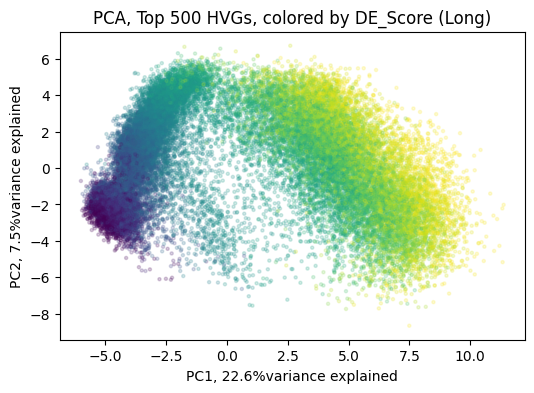

In [ ]:
df = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'DE_score': adata.obs['DE_score_long'].values})
plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['DE_score']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, colored by DE_Score (Long)')
plt.show()

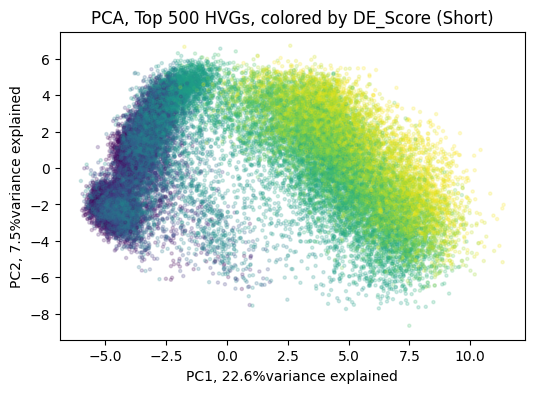

In [ ]:
df = pd.DataFrame({'PC1': adata_hvg.obsm['X_pca'][:,0], 'PC2': adata_hvg.obsm['X_pca'][:,1], 'DE_score': adata.obs['DE_score_short'].values})
plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['DE_score']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, Top 500 HVGs, colored by DE_Score (Short)')
plt.show()

The PCA coloring based on DE score from the long gene list is more similar the coloring by day (aka real time), which probably indicates it's more accurate.  

Next, we'll calculate the average DE scores by donor and plot the changing scores by day as lineplots.

In [ ]:
#Average donor rank by day
adata_DErank_long = adata.obs.groupby(['day', 'donor'], observed=True).agg(mean_DErank_long=('DE_score_long', 'mean')).reset_index() #for long DE_score
adata_DErank_long_pivot = adata_DErank_long.pivot(index='donor', columns='day', values='mean_DErank_long')

adata_DErank_short = adata.obs.groupby(['day', 'donor'], observed=True).agg(mean_DErank_short=('DE_score_short', 'mean')).reset_index() #for short DE_score
adata_DErank_short_pivot = adata_DErank_short.pivot(index='donor', columns='day', values='mean_DErank_short')
adata_DErank_short_pivot

day,day0,day1,day2,day3
donor,,,,
aowh,-2.235540,-1.660856,10.667224,11.694425
aoxv,-1.193244,0.725712,8.859502,8.320449
babz,-0.759983,NaN,7.392440,NaN
bezi,-1.393776,-1.338035,-0.935387,5.597691
bima,NaN,NaN,8.871738,5.003915
...,...,...,...,...
zagm,-0.435118,-0.266820,8.219873,9.849953
zapk,-2.628016,NaN,8.040031,5.776403
zerv,-0.993063,0.256015,6.514312,NaN


In [ ]:
adata_DErank_long_pivot.isna().sum()

,0
day,
day0,14
day1,14
day2,21
day3,17


In [ ]:
#Remove donors with NA as day0 or day3
adata_DErank_long_pivot_clean = adata_DErank_long_pivot.dropna(subset=['day0', 'day3'])
adata_DErank_short_pivot_clean = adata_DErank_short_pivot.dropna(subset=['day0', 'day3'])
adata_DErank_short_pivot_clean.shape

(96, 4)

In [ ]:
#Transform into long dataframes for plotting
adata_DErank_long_pivot_clean = adata_DErank_long_pivot_clean.reset_index().melt(id_vars='donor', var_name='day', value_name='mean_DErank_long')
adata_DErank_short_pivot_clean = adata_DErank_short_pivot_clean.reset_index().melt(id_vars='donor', var_name='day', value_name='mean_DErank_short')
adata_DErank_short_pivot_clean

,donor,day,mean_DErank_short
0,aowh,day0,-2.235540
1,aoxv,day0,-1.193244
2,bezi,day0,-1.393776
3,bokz,day0,-1.604714
4,cicb,day0,-1.829390
...,...,...,...
379,yelp,day3,7.838287
380,yemz,day3,8.582494
381,yoch,day3,5.954285
382,zagm,day3,9.849953


<function matplotlib.pyplot.show(close=None, block=None)>

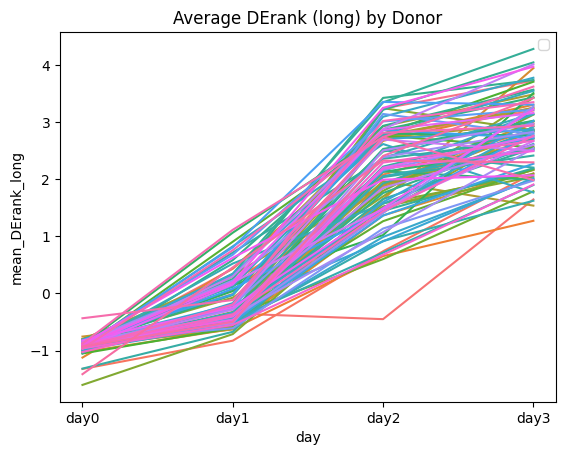

In [ ]:
#Plot donor DE_scores from long gene list
sns.lineplot(data=adata_DErank_long_pivot_clean, x='day', y='mean_DErank_long', hue='donor')
plt.title('Average DErank (long) by Donor')
plt.legend('')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

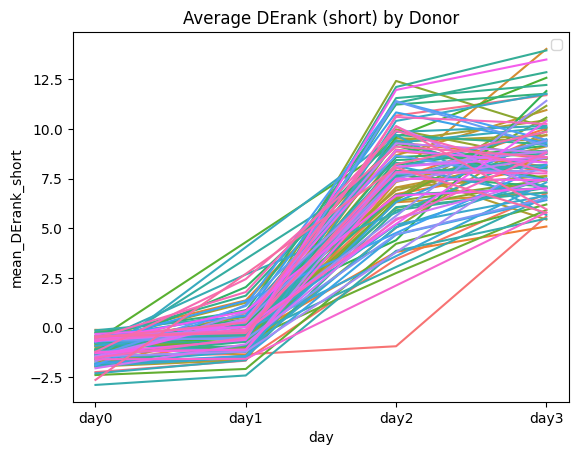

In [ ]:
#Plot donor DE_scores from short gene list
sns.lineplot(data=adata_DErank_short_pivot_clean, x='day', y='mean_DErank_short', hue='donor')
plt.title('Average DErank (short) by Donor')
plt.legend('')
plt.show

Both of these plots look pretty similar to me and both are cleaner than the somparable plot for pseudotime rank.  

DE_Score_long: Has benefit of inclduing more genes, so theoretically more complete measure of DE-ness.

DE_Score_short: Absolute value of the separation bewteen lowest and highest donor is larger, which might be helpful during modelling.

For now, we will keep both scores in the dataset and see which works better and as target during modelling.

The last thing we have to do is add columns for the mean day3 donor scores into adata.

In [ ]:
def slope_chart(data, left_col, right_col, title):
  left=data[left_col].dropna()
  right=data[right_col].dropna()
  donors=data.dropna().index
  fig, ax = plt.subplots(figsize=(6,8))
  for donor in donors:
    ax.plot([0,1],[left.loc[donor], right.loc[donor]], marker='o', linewidth=1)
  ax.set_xticks([0,1])
  ax.set_xticklabels([left_col, right_col])
  ax.set_xlim(-0.1,1.1)
  ax.invert_yaxis()
  ax.set_ylabel('Rank')
  ax.set_title(title)
  plt.tight_layout()
  plt.show()

In [ ]:
print(pd.Series(adata_DErank_long_pivot_clean['mean_DErank_long']))

0     -1.023165
1     -0.993445
2     -0.901560
3     -1.322849
4     -0.799053
         ...   
379    2.939669
380    3.623157
381    1.985998
382    3.424686
383    2.296221
Name: mean_DErank_long, Length: 384, dtype: float64


In [ ]:
pseudorank_day3 = adata_pseudorank_clean_long[adata_pseudorank_clean_long['day'] == 'day3'].set_index('donor')
DElong_day3 = adata_DErank_long_pivot_clean[adata_DErank_long_pivot_clean['day'] == 'day3'].set_index('donor')
DEshort_day3 = adata_DErank_short_pivot_clean[adata_DErank_short_pivot_clean['day'] == 'day3'].set_index('donor')
pseudorank_day3

,day,mean_pseudotime
donor,,
aowh,day3,0.795710
aoxv,day3,0.792407
bezi,day3,0.704033
bokz,day3,0.728495
cicb,day3,0.801028
...,...,...
yelp,day3,0.798859
yemz,day3,0.808366
yoch,day3,0.794238


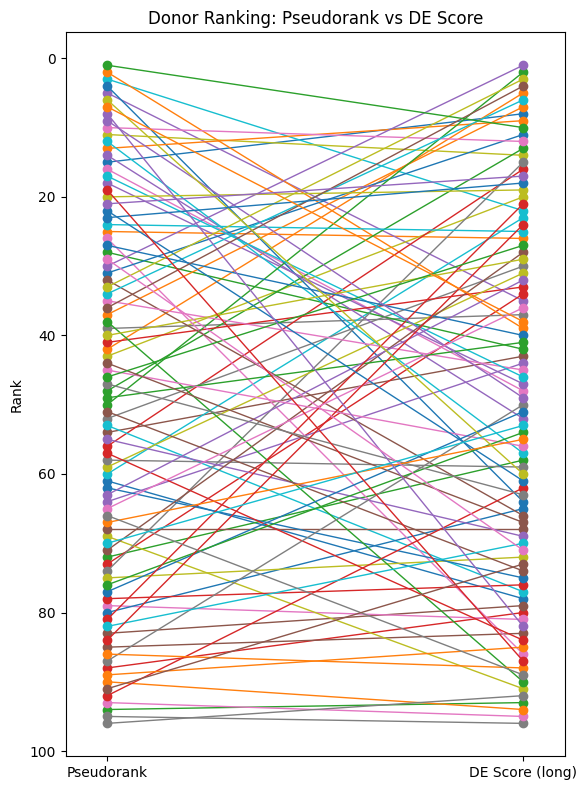

In [ ]:
rank_compare = pd.DataFrame({'Pseudorank':pd.Series(pseudorank_day3['mean_pseudotime'], index=pseudorank_day3.index),
                             'DE Score (long)':pd.Series(DElong_day3['mean_DErank_long'], index=DElong_day3.index),
                             'DE Score (short)':pd.Series(DEshort_day3['mean_DErank_short'], index=DEshort_day3.index)})
rank_compare = rank_compare.rank(ascending=False)
slope_chart(rank_compare, 'Pseudorank', 'DE Score (long)', 'Donor Ranking: Pseudorank vs DE Score')

Clearly, these two ranking systems do not agree with each other.  At this time, we do not have a way of determining which is 'better'.  This would require taking the top donors from each system and differentiating the DE cells fourther, then determining which donors make fully differentiated cell types that most closely resemble endogenous human cells.  For now, we will keep both and see which is better for modelling.

In [ ]:
adata_DErank_short_final = adata_DErank_short_pivot_clean[adata_DErank_short_pivot_clean['day'] == 'day3'] #Subset down to just day3 averages
adata_DErank_long_final = adata_DErank_long_pivot_clean[adata_DErank_long_pivot_clean['day'] == 'day3']

adata_DErank_short_final = adata_DErank_short_final.set_index('donor').drop('day', axis=1) #set donor to index and drop day column
adata_DErank_long_final = adata_DErank_long_final.set_index('donor').drop('day', axis=1)
adata_DErank_long_final

,mean_DErank_long
donor,
aowh,3.726231
aoxv,3.203516
bezi,1.647008
bokz,2.104519
cicb,2.982971
...,...
yelp,2.939669
yemz,3.623157
yoch,1.985998


In [ ]:
adata.obs['mean_DEscore_long'] = adata.obs['donor'].map(adata_DErank_long_final['mean_DErank_long'])
adata.obs['mean_DEscore_short'] = adata.obs['donor'].map(adata_DErank_short_final['mean_DErank_short'])
adata.obs['mean_DEscore_short']

,mean_DEscore_short
21843_1#10,10.564573
21843_1#100,NaN
21843_1#101,NaN
21843_1#102,8.812008
21843_1#103,10.564573
...,...
24539_8#93,8.563316
24539_8#94,9.849953
24539_8#95,7.758178
24539_8#97,7.418418


In [ ]:
adata_short.obs['mean_DEscore_long'] = adata.obs['donor'].map(adata_DErank_long_final['mean_DErank_long'])
adata_short.obs['mean_DEscore_short'] = adata.obs['donor'].map(adata_DErank_short_final['mean_DErank_short'])
adata_short.obs['mean_DEscore_short']

,mean_DEscore_short
21843_1#10,10.564573
21843_1#100,NaN
21843_1#101,NaN
21843_1#102,8.812008
21843_1#103,10.564573
...,...
24539_8#93,8.563316
24539_8#94,9.849953
24539_8#95,7.758178
24539_8#97,7.418418


The NaN mean that donor didn't have any cells in day0 and or day3.  These donors will be removed in Data Wrangling.

In [ ]:
#Save to make a stop point
adata.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V4.h5ad")
adata_short.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_EDA_V4.h5ad")

In [ ]:
#Load file if necessary
#adata = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_EDA_V4.h5ad")
#adata_short = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_EDA_V4.h5ad")

##Data Wrangling: Customize dataset for Modelling
In our model, we want to use the data for day0 to predict differentiation efficiency.  

We will make two final datasets, one for modelling based on DE_Score with all cells, and the other for modelling based on pseudorank where a subset of day0 cells are removed.

Step 1: Determine if all donors are represented in data from all days.

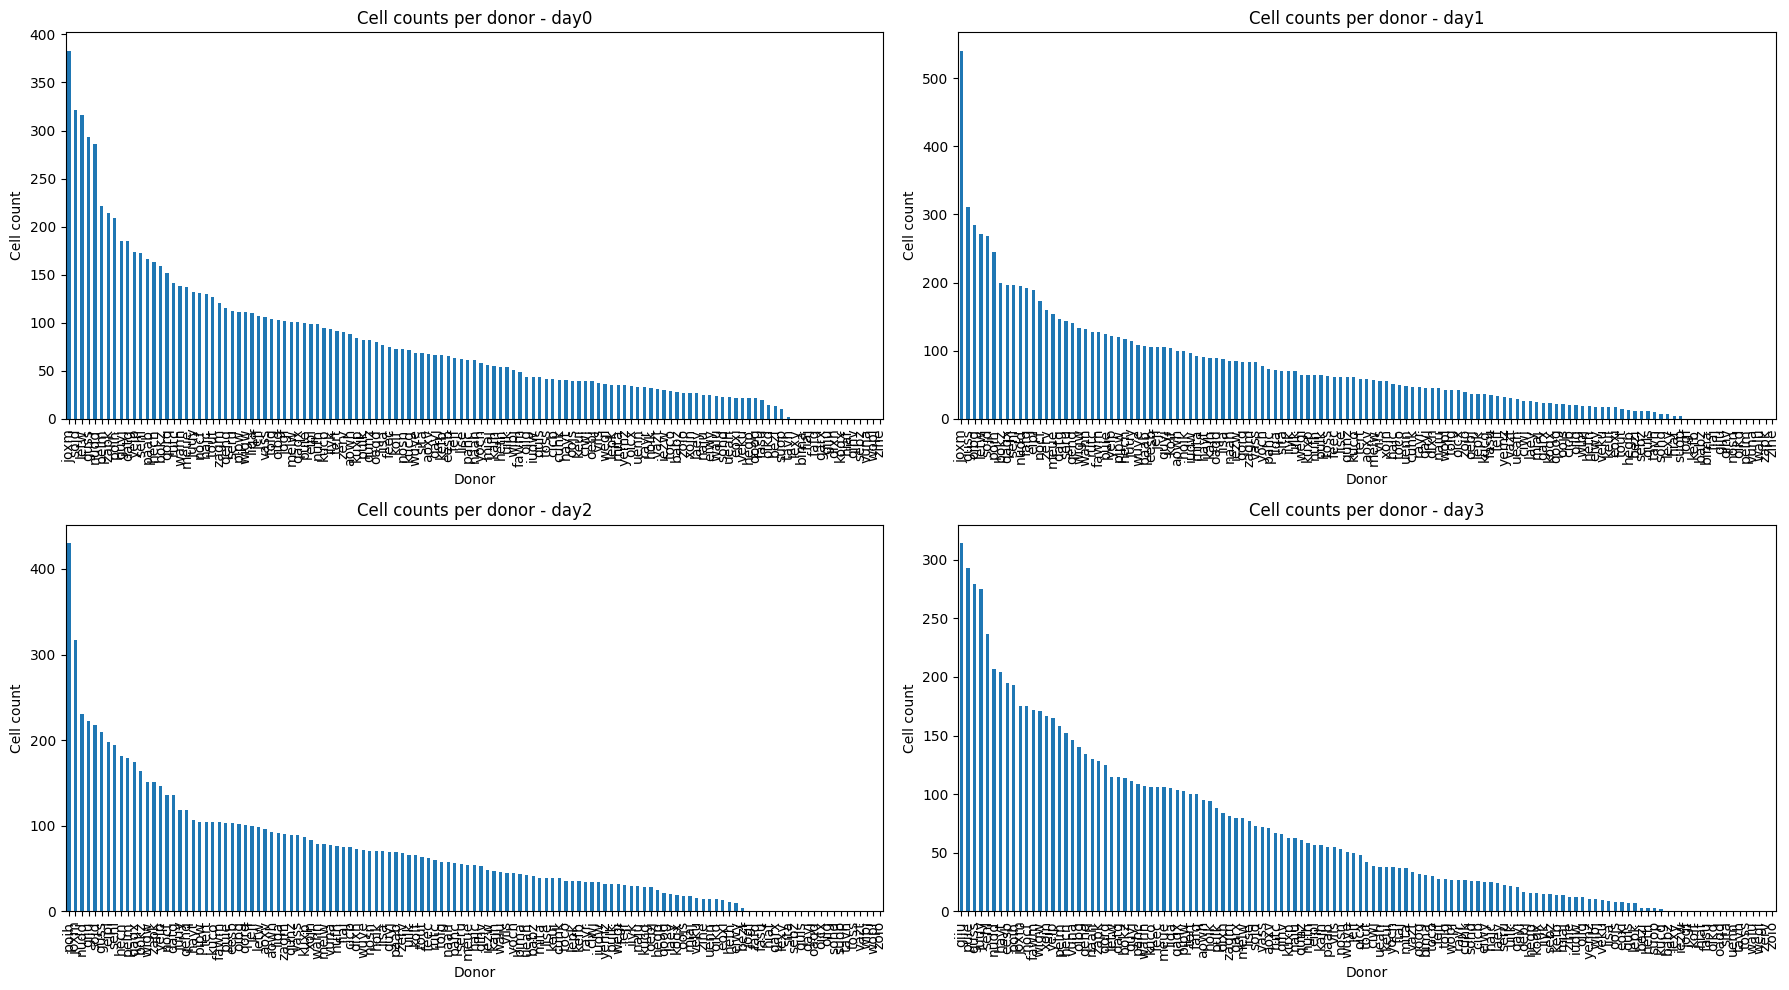

In [ ]:
# Get unique days
day_order = ['day0', 'day1', 'day2', 'day3']
days = adata.obs['day'].unique()
# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, day in enumerate(day_order):
    subset = adata.obs[adata.obs['day'] == day]
    counts = subset['donor'].value_counts()
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Cell counts per donor - {day}')
    axes[i].set_xlabel('Donor')
    axes[i].set_ylabel('Cell count')
    axes[i].tick_params(axis='x', rotation=90)  # rotate donor labels

plt.tight_layout()
plt.show()

We can see that cells from all donors are not present in each day.  We are most interested in day0 and day3. In our work above looking at donor ranks, we allowed any donor with at least one cell in day0 and at least one cell in day3.  That gave us 96 donors.

For modelling, it would be better if each donor has multiple cells in day0 and day3.  Let's pick 5 cells as a threshold.

Step 2: Make a list of donors in both day0 and day3.

In [ ]:
day_0 = adata.obs[adata.obs['day'] == 'day0']
day_0_counts = day_0['donor'].value_counts()
day_0_counts = day_0_counts[day_0_counts>= 5]
print(day_0_counts)

donor
joxm    383
sojd    321
letw    316
guss    293
nudd    286
       ... 
qoog     22
fasu     20
oikd     15
bezi     13
suop     10
Name: count, Length: 110, dtype: int64


In [ ]:
day_3 = adata.obs[adata.obs['day'] == 'day3']
day_3_counts = day_3['donor'].value_counts()
day_3_counts = day_3_counts[day_3_counts >= 5]
print(day_3_counts)

donor
giju    314
puie    293
guss    279
juuy    275
sehl    237
       ... 
iisa      9
oojs      8
eoxi      8
quls      7
lepk      7
Name: count, Length: 104, dtype: int64


In [ ]:
common_donors = day_0_counts.index.intersection(day_3_counts.index)
common_donors = list(common_donors)
print(len(common_donors))

92


We have 92 donors making the cut.

Step 3: Remove cells from donors not in common donor list.

In [ ]:
#Make adata version that only has final donor cut.
adata_DEscores = adata[adata.obs['donor'].isin(common_donors)].copy()

There is way more than we need in the metadata of this file.  Look at the metadata colums and keep only the ones we made or used in this analysis.

In [ ]:
adata_DEscores.obs.columns

Index(['assigned', 'auxDir', 'cell_filter', 'cell_name',
       'compatible_fragment_ratio', 'day', 'donor', 'expected_format',
       'experiment', 'frag_dist_length', 'gc_bias_correct', 'is_cell_control',
       'is_cell_control_bulk', 'is_cell_control_control', 'library_types',
       'libType', 'log10_total_counts', 'log10_total_counts_endogenous',
       'log10_total_counts_ERCC', 'log10_total_counts_feature_control',
       'log10_total_counts_MT', 'log10_total_features',
       'log10_total_features_endogenous', 'log10_total_features_ERCC',
       'log10_total_features_feature_control', 'log10_total_features_MT',
       'mapping_type', 'mates1', 'mates2', 'n_alt_reads', 'n_total_reads',
       'num_assigned_fragments', 'num_bias_bins', 'num_bootstraps',
       'num_compatible_fragments', 'num_consistent_mappings',
       'num_inconsistent_mappings', 'num_libraries', 'num_mapped',
       'num_processed', 'num_targets', 'nvars_used', 'pct_counts_endogenous',
       'pct_counts_ERC

In [ ]:
adata_DEscores.obs = adata_DEscores.obs[['cell_name', 'day', 'donor','DE_score_long', 'DE_score_short', 'mean_DEscore_long', 'mean_DEscore_short', 'mean_pseudorank', 'dpt_pseudotime', '2000_pseudotime']]
adata_DEscores.obs.columns

Index(['cell_name', 'day', 'donor', 'DE_score_long', 'DE_score_short',
       'mean_DEscore_long', 'mean_DEscore_short', 'mean_pseudorank',
       'dpt_pseudotime', '2000_pseudotime'],
      dtype='object')

 Step 4: Split this into scanpy objects for each separate day of differentiation.

In [ ]:
adata_DEscores_day0 = adata_DEscores[adata_DEscores.obs['day'] == 'day0'].copy()
adata_DEscores_day1 = adata_DEscores[adata_DEscores.obs['day'] == 'day0'].copy()
adata_DEscores_day2 = adata_DEscores[adata_DEscores.obs['day'] == 'day0'].copy()
adata_DEscores_day3 = adata_DEscores[adata_DEscores.obs['day'] == 'day0'].copy()
adata_DEscores_day0.shape

(8841, 11231)

In [ ]:
#Save ScanPy files
adata_DEscores_day0.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_DEscores_day0.h5ad")
adata_DEscores_day1.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_DEscores_day1.h5ad")
adata_DEscores_day2.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_DEscores_day2.h5ad")
adata_DEscores_day3.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_DEscores_day3.h5ad")
adata_DEscores.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_DEscores.h5ad")

Finally, we need to repeat this for our files for modelling based on pseudorank.  The only difference is that we will remove day0 cells where dpt_pseudotime >=0.61 before subsetting and saving.

In [ ]:
mask = ~((adata_DEscores.obs['day'] == 'day0') & (adata_DEscores.obs['dpt_pseudotime'] >= 0.55))
adata_pseudorank_final = adata_DEscores[mask].copy()
adata_pseudorank_final.obs.columns

Index(['cell_name', 'day', 'donor', 'DE_score_long', 'DE_score_short',
       'mean_DEscore_long', 'mean_DEscore_short', 'mean_pseudorank',
       'dpt_pseudotime', '2000_pseudotime'],
      dtype='object')

 Step 4: Split this into scanpy objects for each separate day of differentiation.

In [ ]:
adata_pseudorank_day0 = adata_pseudorank_final[adata_pseudorank_final.obs['day'] == 'day0'].copy()
adata_pseudorank_day1 = adata_pseudorank_final[adata_pseudorank_final.obs['day'] == 'day0'].copy()
adata_pseudorank_day2 = adata_pseudorank_final[adata_pseudorank_final.obs['day'] == 'day0'].copy()
adata_pseudorank_day3 = adata_pseudorank_final[adata_pseudorank_final.obs['day'] == 'day0'].copy()
adata_pseudorank_day0.shape

(8102, 11231)

In [ ]:
#Save ScanPy files
adata_pseudorank_day0.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_day0.h5ad")
adata_pseudorank_day1.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_day1.h5ad")
adata_pseudorank_day2.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_day2.h5ad")
adata_pseudorank_day3.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_day3.h5ad")
adata_pseudorank_final.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/adata_pseudorank_final.h5ad")